<a href="https://colab.research.google.com/github/neuish/Vitamin_D_Project/blob/main/Vitamin_D_Prediction_Full_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Problem Statement

•	Analyze the statistical correlation between serum concentrations of 25(OH)D and important factors like the duration of exposure to the sun, geographical area as defined by latitude, and lifestyle factors.


•	Train and evaluate several supervised models such as logistic regression, XGBoost, CatBoost, Tabnet etc, that efficiently predict individuals who are at risk of being deficient.


•	Implement the Explainable AI techniques such as SHAP in order to ensure the explanation of the impact of the demographic and lifestyle factors in an interpretable form.


•	Design and deploy the web-based dashboards and insights visualization of data results to be shared with healthcare practitioners and data experts alike.



In [ ]:
import sys
# Install necessary packages
!{sys.executable} -m pip install catboost pytorch-tabnet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import shap
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# This cell is now merged with the installation cell above to ensure all imports are at the start.
# No changes needed in this cell. Its content has been moved.

# 2. Data Loading and Describing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Logistic Regression/Vitamin_D_Dataset.csv')

In [ ]:
# first few rows of data

df.head()

,age,bmi,sun_hours_per_day,screen_time_hours,calcium_intake_mg,vitaminD_supplement_dose_IU,latitude_deg,outdoor_activity_minutes,diet_score,sleep_hours,...,season,physical_activity_level,diet_type,socioeconomic_status,education_level,smoking_status,alcohol_use,urban_rural,vitaminD_ng_ml,deficient_label
0,48,24.704992,5.388847,7.822940,481.870343,0,23.387283,53.132966,5.598435,7.896034,...,Winter,Low,Non-veg,Middle,Graduate,Non-smoker,Yes,Urban,16.489554,1
1,36,18.883132,2.578413,6.919658,967.785209,1000,33.393709,81.746428,3.278181,7.335898,...,Monsoon,Moderate,Non-veg,Middle,Secondary,Non-smoker,No,Rural,16.872776,1
2,48,22.202328,6.913801,3.833820,878.614331,400,20.668296,70.002850,5.751364,4.490197,...,Spring,Low,Non-veg,Low,Graduate,Non-smoker,Yes,Urban,23.934443,0
3,30,24.658394,7.489518,7.155493,300.000000,0,32.977726,63.822784,8.216929,7.508073,...,Monsoon,Moderate,Non-veg,Middle,Postgraduate,Non-smoker,No,Urban,21.460801,0
4,74,25.547911,2.403983,8.790671,894.374742,800,17.192737,69.515129,4.040100,8.651286,...,Monsoon,Low,Mixed,Middle,Postgraduate,Smoker,Yes,Urban,14.009061,1


In [ ]:
#  data information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          10000 non-null  int64  
 1   bmi                          10000 non-null  float64
 2   sun_hours_per_day            10000 non-null  float64
 3   screen_time_hours            10000 non-null  float64
 4   calcium_intake_mg            10000 non-null  float64
 5   vitaminD_supplement_dose_IU  10000 non-null  int64  
 6   latitude_deg                 10000 non-null  float64
 7   outdoor_activity_minutes     10000 non-null  float64
 8   diet_score                   10000 non-null  float64
 9   sleep_hours                  10000 non-null  float64
 10  cholesterol_level_mgdl       10000 non-null  float64
 11  body_fat_percentage          10000 non-null  float64
 12  serum_calcium_mgdl           10000 non-null  float64
 13  sex              

In [ ]:
# describing data


df.describe()

,age,bmi,sun_hours_per_day,screen_time_hours,calcium_intake_mg,vitaminD_supplement_dose_IU,latitude_deg,outdoor_activity_minutes,diet_score,sleep_hours,cholesterol_level_mgdl,body_fat_percentage,serum_calcium_mgdl,vitaminD_ng_ml,deficient_label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.531700,23.990007,4.270745,5.495023,705.113976,491.660000,22.546853,60.035959,5.972677,6.964473,179.564273,24.961340,9.194492,21.316680,0.405600
std,17.824247,3.914229,2.171903,2.602268,237.303070,526.427732,8.365684,29.310643,1.975767,1.465492,30.006006,6.848415,0.500895,5.203584,0.491032
min,18.000000,16.000000,0.500669,1.000854,300.000000,0.000000,8.000600,0.000000,0.000000,3.000000,100.000000,10.000000,7.500000,5.000000,0.000000
25%,33.000000,21.251287,2.397303,3.265333,532.827692,0.000000,15.414647,39.486387,4.622339,5.950184,159.180573,20.197551,8.854299,17.681899,0.000000
50%,49.000000,23.954753,4.269302,5.449168,703.407416,400.000000,22.470903,59.946250,5.996280,6.978372,179.346633,24.937536,9.202850,21.212827,0.000000
75%,64.000000,26.681251,6.154501,7.738790,868.196356,800.000000,29.787257,79.909425,7.351095,8.008932,199.980467,29.616033,9.536056,24.942650,1.000000
max,79.000000,38.862701,7.999071,9.999904,1500.000000,2000.000000,36.992565,166.688705,10.000000,10.000000,280.000000,45.000000,11.000000,40.133243,1.000000


## 2.1. Data Cleaning and treating

In [ ]:
# count null

df.isnull().sum()


,0
age,0
bmi,0
sun_hours_per_day,0
screen_time_hours,0
calcium_intake_mg,0
vitaminD_supplement_dose_IU,0
latitude_deg,0
outdoor_activity_minutes,0
diet_score,0
sleep_hours,0


In [ ]:
# Drop rows with any null values
df.dropna(inplace=True)


In [ ]:
# Count duplicates based on all columns
duplicate_rows = df[df.duplicated()]
num_duplicates = len(duplicate_rows)
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [ ]:
df.columns = [
    'age',
    'bmi',
    'sun_hours_per_day',
    'screen_time_hours',
    'calcium_intake_mg',
    'vitamin_d_supplement_iu',
    'latitude_deg',
    'outdoor_activity_minutes',
    'diet_score',
    'sleep_hours',
    'cholesterol_mg_dl',
    'body_fat_percentage',
    'serum_calcium_mg_dl',
    'sex',
    'skin_tone',
    'clothing_coverage',
    'season',
    'physical_activity_level',
    'diet_type',
    'socioeconomic_status',
    'education_level',
    'smoking_status',
    'alcohol_use',
    'urban_rural',
    'vitamin_d_ng_ml',
    'deficient_label'
]


In [ ]:
print(f"Number of rows in the DataFrame: {df.shape[0]}")

Number of rows in the DataFrame: 10000


In [ ]:
# Rename the specific column
df.rename(columns={'deficient_label': 'deficient'}, inplace=True)

# Check the change
print(df.columns)


Index(['age', 'bmi', 'sun_hours_per_day', 'screen_time_hours',
       'calcium_intake_mg', 'vitamin_d_supplement_iu', 'latitude_deg',
       'outdoor_activity_minutes', 'diet_score', 'sleep_hours',
       'cholesterol_mg_dl', 'body_fat_percentage', 'serum_calcium_mg_dl',
       'sex', 'skin_tone', 'clothing_coverage', 'season',
       'physical_activity_level', 'diet_type', 'socioeconomic_status',
       'education_level', 'smoking_status', 'alcohol_use', 'urban_rural',
       'vitamin_d_ng_ml', 'deficient'],
      dtype='object')


In [ ]:
print(df.head())


   age        bmi  sun_hours_per_day  screen_time_hours  calcium_intake_mg  \
0   48  24.704992           5.388847           7.822940         481.870343   
1   36  18.883132           2.578413           6.919658         967.785209   
2   48  22.202328           6.913801           3.833820         878.614331   
3   30  24.658394           7.489518           7.155493         300.000000   
4   74  25.547911           2.403983           8.790671         894.374742   

   vitamin_d_supplement_iu  latitude_deg  outdoor_activity_minutes  \
0                        0     23.387283                 53.132966   
1                     1000     33.393709                 81.746428   
2                      400     20.668296                 70.002850   
3                        0     32.977726                 63.822784   
4                      800     17.192737                 69.515129   

   diet_score  sleep_hours  ...   season  physical_activity_level  diet_type  \
0    5.598435     7.896034  ..

## 3. Visualization on Vitamin D Deficiency
### Vitamin D Deficiency Risk Surface: Sun Hours vs. Supplementation

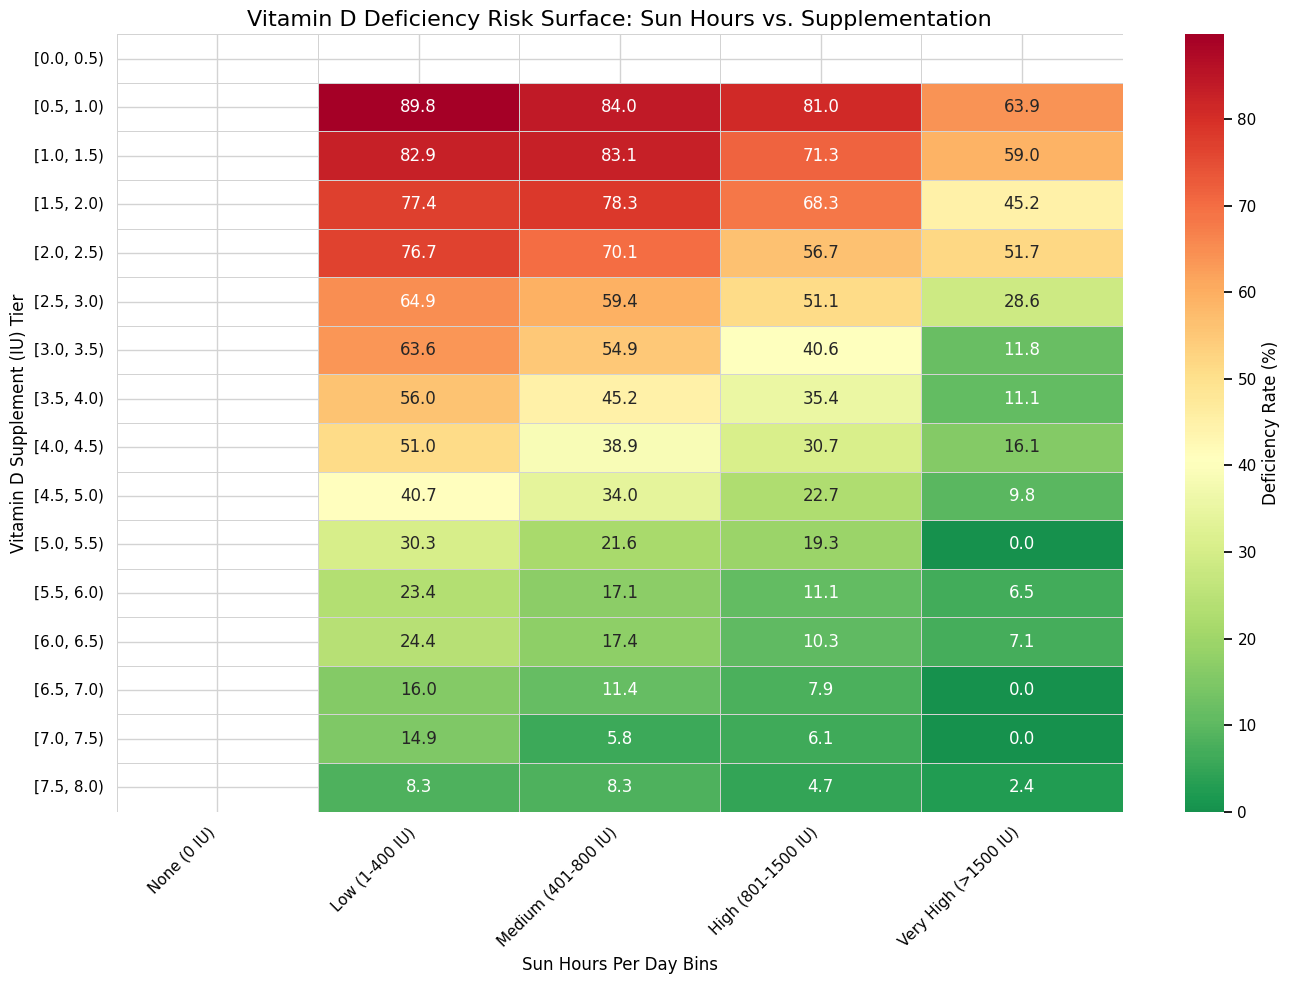

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set Matplotlib rcParams for a light theme
plt.rcParams.update({
    'figure.facecolor': 'white', # White background for the figure
    'axes.facecolor': 'white',   # White background for the plot area
    'text.color': 'black',       # Black text color
    'axes.labelcolor': 'black',  # Black axis label color
    'xtick.color': 'black',      # Black x-tick color
    'ytick.color': 'black',      # Black y-tick color
    'grid.color': 'lightgray',   # Light gray grid lines (if any)
    'axes.edgecolor': 'gray',    # Gray plot border
    'savefig.facecolor': 'white', # Ensure saved figure also has white background
})

# Create tiers for vitaminD_supplement_dose_IU
# Using descriptive labels for better readability on the Y-axis
df['supplement_tier'] = pd.cut(df['vitamin_d_supplement_iu'],
                               bins=[-1, 0, 400, 800, 1500, 2001],
                               labels=['None (0 IU)', 'Low (1-400 IU)', 'Medium (401-800 IU)', 'High (801-1500 IU)', 'Very High (>1500 IU)'],
                               right=False)

# Create bins for sun_hours_per_day (from 0 to 8.5 hours in 0.5-hour intervals)
df['sun_hours_bins'] = pd.cut(df['sun_hours_per_day'], bins=np.arange(0, 8.5, 0.5), right=False)

# Calculate deficiency rate for each combination of sun hours bins and supplement tiers
risk_surface = df.groupby(['sun_hours_bins', 'supplement_tier'])['deficient'].mean().unstack()

# Get overall deficiency prevalence for centering the diverging colormap
overall_deficiency = df['deficient'].mean()

plt.figure(figsize=(14, 10))
sns.heatmap(risk_surface * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=overall_deficiency * 100, linewidths=.5, linecolor='lightgrey',
            cbar_kws={'label': 'Deficiency Rate (%)'})

plt.title('Vitamin D Deficiency Risk Surface: Sun Hours vs. Supplementation', fontsize=16)
plt.xlabel('Sun Hours Per Day Bins', fontsize=12)
plt.ylabel('Vitamin D Supplement (IU) Tier', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 1. Vitamin D Distribution & Deficiency Threshold

This violin plot provides a rich visualization of the distribution shape and density of vitamin D levels for both deficient and non-deficient individuals, offering more detail than a traditional boxplot.

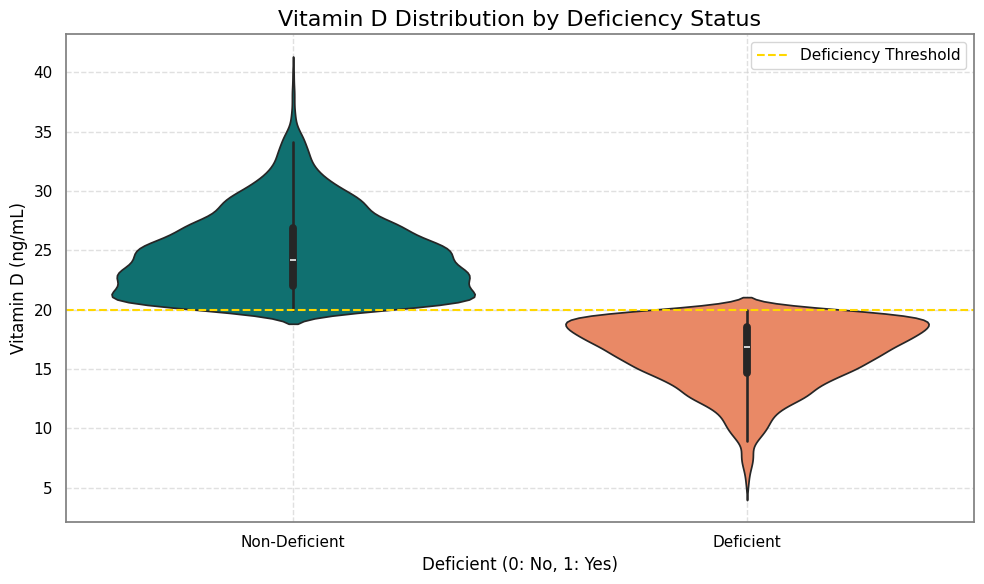

In [ ]:
# Re-apply light theme settings for consistency
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'lightgray',
    'axes.edgecolor': 'gray',
    'savefig.facecolor': 'white',
})

plt.figure(figsize=(10, 6))
sns.violinplot(x='deficient', y='vitamin_d_ng_ml', data=df, palette={0: 'teal', 1: 'coral'}, hue='deficient', legend=False)
plt.axhline(20, color='gold', linestyle='--', label='Deficiency Threshold')
plt.title('Vitamin D Distribution by Deficiency Status', fontsize=16)
plt.xlabel('Deficient (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Vitamin D (ng/mL)', fontsize=12)
plt.xticks([0, 1], ['Non-Deficient', 'Deficient'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Age Distribution for Deficient vs. Non-Deficient

This plot compares the age distribution between individuals who are vitamin D deficient and those who are not. It helps identify if certain age groups are more susceptible to deficiency.

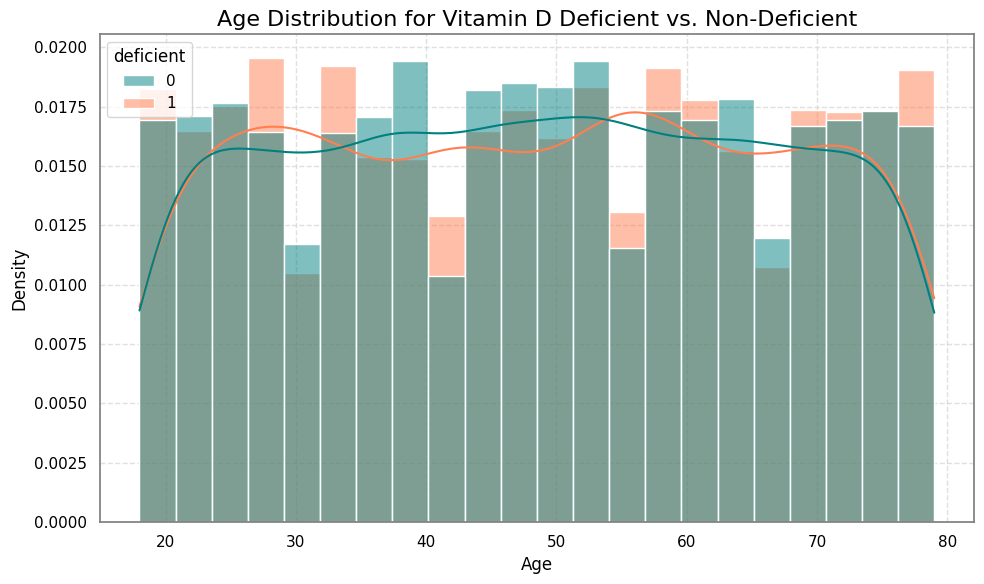

In [ ]:
# Re-apply light theme settings for consistency
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'lightgray',
    'axes.edgecolor': 'gray',
    'savefig.facecolor': 'white',
})

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='deficient', kde=True, palette={0: 'teal', 1: 'coral'}, stat='density', common_norm=False)
plt.title('Age Distribution for Vitamin D Deficient vs. Non-Deficient', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4. Body Fat Percentage vs. Vitamin D Levels

This scatter plot explores a significant physiological factor, as Vitamin D is fat-soluble and its sequestration in adipose tissue is a known mechanism of deficiency. It highlights deficient individuals.

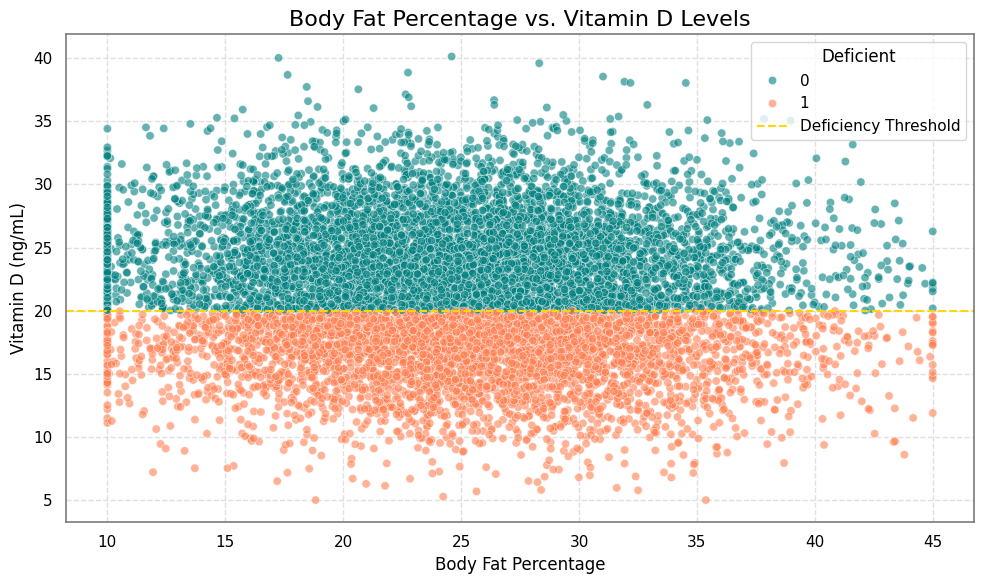

In [ ]:
# Re-apply light theme settings for consistency
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'lightgray',
    'axes.edgecolor': 'gray',
    'savefig.facecolor': 'white',
})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='body_fat_percentage', y='vitamin_d_ng_ml', hue='deficient', data=df, palette={0: 'teal', 1: 'coral'}, alpha=0.6)
plt.axhline(20, linestyle='--', color='gold', label='Deficiency Threshold')
plt.title('Body Fat Percentage vs. Vitamin D Levels', fontsize=16)
plt.xlabel('Body Fat Percentage', fontsize=12)
plt.ylabel('Vitamin D (ng/mL)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Deficient')
plt.tight_layout()
plt.show()

### 5. Sun Exposure vs. Vitamin D Level by Skin Tone

This plot is essential for understanding the primary natural source of Vitamin D and how biological factors (melanin) modify its effectiveness. Regression lines for each skin tone group further clarify these differences.

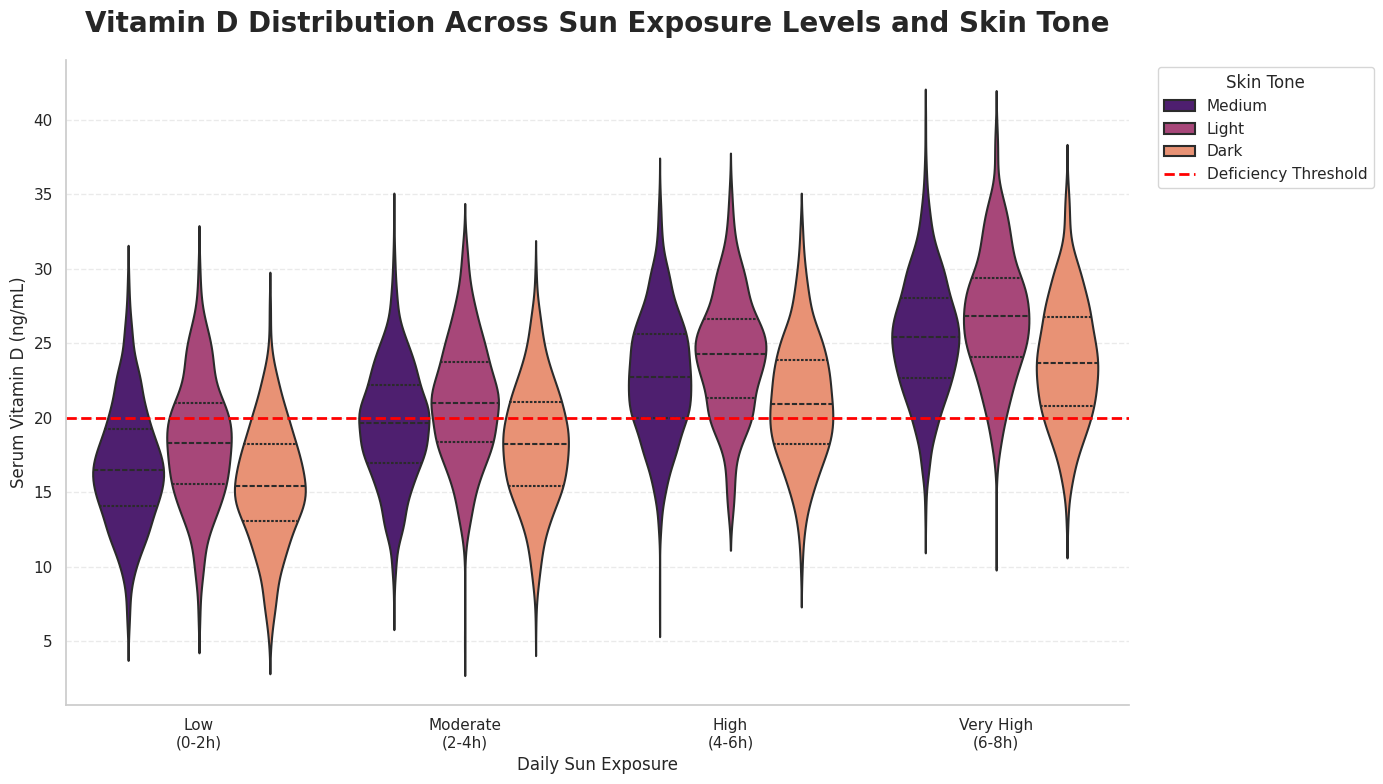

In [ ]:
df['sun_exposure_group'] = pd.cut(
    df['sun_hours_per_day'],
    bins=[0, 2, 4, 6, 8],
    labels=[
        'Low\n(0-2h)',
        'Moderate\n(2-4h)',
        'High\n(4-6h)',
        'Very High\n(6-8h)'
    ]
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 8))

sns.violinplot(
    data=df,
    x='sun_exposure_group',
    y='vitamin_d_ng_ml',
    hue='skin_tone',
    palette='magma',
    split=False,
    inner='quartile',
    linewidth=1.5
)

plt.axhline(
    20,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Deficiency Threshold'
)

plt.title(
    'Vitamin D Distribution Across Sun Exposure Levels and Skin Tone',
    fontsize=20,
    weight='bold',
    pad=20
)

plt.xlabel('Daily Sun Exposure')
plt.ylabel('Serum Vitamin D (ng/mL)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(
    title='Skin Tone',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine()

plt.tight_layout()
plt.show()

### 6. Stacked Bar Chart of Deficiency Prevalence by Skin Tone and Season

This visualization reveals complex interactions between two major environmental and biological risk factors, showing their combined effects on Vitamin D deficiency prevalence.

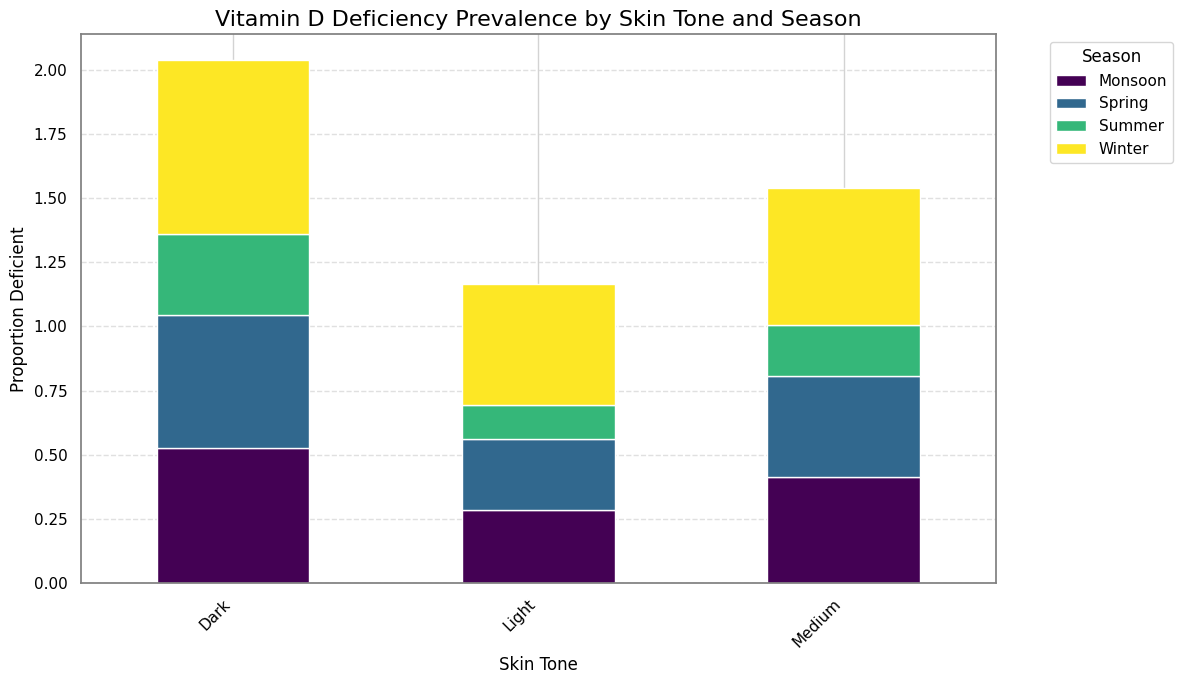

In [ ]:
# Re-apply light theme settings for consistency
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'lightgray',
    'axes.edgecolor': 'gray',
    'savefig.facecolor': 'white',
})

# Calculate deficiency prevalence for each combination
deficiency_crosstab = df.groupby(['skin_tone', 'season'])['deficient'].mean().unstack()

plt.figure(figsize=(12, 7))
deficiency_crosstab.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())
plt.title('Vitamin D Deficiency Prevalence by Skin Tone and Season', fontsize=16)
plt.xlabel('Skin Tone', fontsize=12)
plt.ylabel('Proportion Deficient', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 7. Heatmap of Median Vitamin D by Supplementation Tier and Sun Hours Quartile

This heatmap provides crucial insights into potential interventions, showing how supplementation can mitigate the impact of low sun exposure by displaying median Vitamin D levels across different tiers of supplementation and sun exposure quartiles.

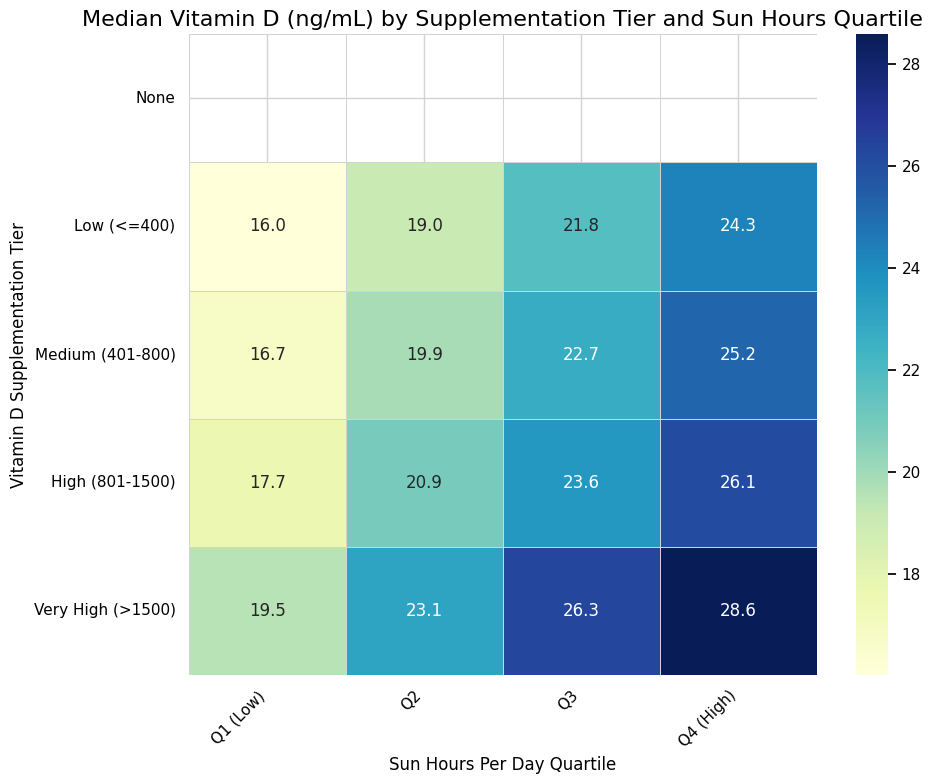

In [ ]:
# Re-apply light theme settings for consistency
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'lightgray',
    'axes.edgecolor': 'gray',
    'savefig.facecolor': 'white',
})

# Create tiers for vitaminD_supplement_dose_IU
df['supplement_tier'] = pd.cut(df['vitamin_d_supplement_iu'], bins=[-1, 0, 400, 800, 1500, 2001], labels=['None', 'Low (<=400)', 'Medium (401-800)', 'High (801-1500)', 'Very High (>1500)'], right=False)

# Create quartiles for sun_hours_per_day
df['sun_hours_quartile'] = pd.qcut(df['sun_hours_per_day'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

# Calculate median vitamin D for each combination
median_vd_heatmap = df.groupby(['supplement_tier', 'sun_hours_quartile'])['vitamin_d_ng_ml'].median().unstack()

plt.figure(figsize=(10, 8))
sns.heatmap(median_vd_heatmap, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5, linecolor='lightgrey')
plt.title('Median Vitamin D (ng/mL) by Supplementation Tier and Sun Hours Quartile', fontsize=16)
plt.xlabel('Sun Hours Per Day Quartile', fontsize=12)
plt.ylabel('Vitamin D Supplementation Tier', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [ ]:
df = df.drop('vitamin_d_ng_ml', axis=1)
print(df.head())

   age        bmi  sun_hours_per_day  screen_time_hours  calcium_intake_mg  \
0   48  24.704992           5.388847           7.822940         481.870343   
1   36  18.883132           2.578413           6.919658         967.785209   
2   48  22.202328           6.913801           3.833820         878.614331   
3   30  24.658394           7.489518           7.155493         300.000000   
4   74  25.547911           2.403983           8.790671         894.374742   

   vitamin_d_supplement_iu  latitude_deg  outdoor_activity_minutes  \
0                        0     23.387283                 53.132966   
1                     1000     33.393709                 81.746428   
2                      400     20.668296                 70.002850   
3                        0     32.977726                 63.822784   
4                      800     17.192737                 69.515129   

   diet_score  sleep_hours  ...  socioeconomic_status  education_level  \
0    5.598435     7.896034  ...     

In [ ]:
print(df['age'].unique())
print(df['deficient'].unique())


[48 36 30 74 21 37 50 40 55 28 32 51 58 41 65 38 34 18 71 54 43 35 73 29
 63 46 27 45 31 69 44 59 60 78 33 49 70 23 39 25 56 42 68 26 72 57 79 52
 77 67 22 64 75 19 53 66 24 47 61 20 62 76]
[1 0]


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns identified:", categorical_cols)


Categorical columns identified: ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural']


In [ ]:
df['deficient'] = df['deficient'].astype('object')
print(f"Data type of 'deficient' column after conversion: {df['deficient'].dtype}")

Data type of 'deficient' column after conversion: object


In [ ]:
continuous_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Continuous Columns:", continuous_cols)
print("\nCategorical Columns:", categorical_cols)

Continuous Columns: ['age', 'bmi', 'sun_hours_per_day', 'screen_time_hours', 'calcium_intake_mg', 'vitamin_d_supplement_iu', 'latitude_deg', 'outdoor_activity_minutes', 'diet_score', 'sleep_hours', 'cholesterol_mg_dl', 'body_fat_percentage', 'serum_calcium_mg_dl']

Categorical Columns: ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural', 'deficient']


In [ ]:
categorical_cols_to_encode = ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural']

df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

columns_to_print = ['sex_Male', 'skin_tone_Fair', 'skin_tone_Medium', 'clothing_coverage_Low', 'clothing_coverage_Medium', 'season_Monsoon', 'season_Spring', 'season_Summer', 'physical_activity_level_Moderate', 'physical_activity_level_Sedentary', 'diet_type_Non-veg', 'diet_type_Veg', 'socioeconomic_status_Low', 'socioeconomic_status_Middle', 'education_level_Postgraduate', 'education_level_Secondary', 'smoking_status_Smoker', 'alcohol_use_Yes', 'urban_rural_Urban']

# Filter out columns that might not exist in df_encoded due to drop_first=True or other reasons
existing_columns_to_print = [col for col in columns_to_print if col in df_encoded.columns]

# Print only the existing columns
print(df_encoded[existing_columns_to_print].head())

   sex_Male  skin_tone_Medium  clothing_coverage_Low  \
0     False              True                   True   
1      True             False                   True   
2      True             False                  False   
3     False              True                  False   
4     False              True                  False   

   clothing_coverage_Medium  season_Spring  season_Summer  \
0                     False          False          False   
1                     False          False          False   
2                     False           True          False   
3                     False          False          False   
4                     False          False          False   

   physical_activity_level_Moderate  diet_type_Non-veg  diet_type_Veg  \
0                             False               True          False   
1                              True               True          False   
2                             False               True          False   
3   

In [ ]:
for col in df_encoded.select_dtypes(include='bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)

print("DataFrame after converting boolean columns to integers:")
print(df_encoded[existing_columns_to_print].head())

DataFrame after converting boolean columns to integers:
   sex_Male  skin_tone_Medium  clothing_coverage_Low  \
0         0                 1                      1   
1         1                 0                      1   
2         1                 0                      0   
3         0                 1                      0   
4         0                 1                      0   

   clothing_coverage_Medium  season_Spring  season_Summer  \
0                         0              0              0   
1                         0              0              0   
2                         0              1              0   
3                         0              0              0   
4                         0              0              0   

   physical_activity_level_Moderate  diet_type_Non-veg  diet_type_Veg  \
0                                 0                  1              0   
1                                 1                  1              0   
2                    

### 4.1. Grouping Age and VitaminD Supplement IU

In [ ]:
# Define bins and labels for Age Group (already defined in kernel state)
age_bins = [0, 20, 30, 40, 50, 60, 70, float('inf')]
age_labels = ['Below 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']

# Define bins and labels for Vitamin D Supplement IU (already defined in kernel state)
delay_bins = [0, 400, 800, 1000, 2000, float('inf')]
delay_labels = ['0', '400', '800', '1000', '2000+']

# Create 'Age_Group' column based on bins
df['Age_Group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Create 'VitaminD_Supplement_Group' column based on bins
df['VitaminD_Supplement_Group'] = pd.cut(df['vitamin_d_supplement_iu'], bins=delay_bins, labels=delay_labels, right=False)

print("DataFrame after adding Age_Group and VitaminD_Supplement_Group:")
print(df[['age', 'Age_Group', 'vitamin_d_supplement_iu', 'VitaminD_Supplement_Group']].head())

DataFrame after adding Age_Group and VitaminD_Supplement_Group:
   age Age_Group  vitamin_d_supplement_iu VitaminD_Supplement_Group
0   48     40-49                        0                         0
1   36     30-39                     1000                      1000
2   48     40-49                      400                       400
3   30     30-39                        0                         0
4   74       70+                      800                       800


In [ ]:
print(f"Data type of 'Age_Group': {df['Age_Group'].dtype}")
print(f"Unique values in 'Age_Group': {df['Age_Group'].unique().tolist()}")
print(f"\nData type of 'VitaminD_Supplement_Group': {df['VitaminD_Supplement_Group'].dtype}")
print(f"Unique values in 'VitaminD_Supplement_Group': {df['VitaminD_Supplement_Group'].unique().tolist()}")

Data type of 'Age_Group': category
Unique values in 'Age_Group': ['40-49', '30-39', '70+', '20-29', '50-59', '60-69', 'Below 20']

Data type of 'VitaminD_Supplement_Group': category
Unique values in 'VitaminD_Supplement_Group': ['0', '1000', '400', '800', '2000+']


In [ ]:
# One-hot encode 'Age_Group' and 'VitaminD_Supplement_Group'
df_age_vitd_encoded = pd.get_dummies(df[['Age_Group', 'VitaminD_Supplement_Group']], drop_first=True)

# Convert boolean columns to integers
for col in df_age_vitd_encoded.select_dtypes(include='bool').columns:
    df_age_vitd_encoded[col] = df_age_vitd_encoded[col].astype(int)

# Merge with df_encoded
df_encoded = pd.concat([df_encoded, df_age_vitd_encoded], axis=1)

print("Head of df_encoded after adding one-hot encoded Age_Group and VitaminD_Supplement_Group:")
print(df_encoded.head())

Head of df_encoded after adding one-hot encoded Age_Group and VitaminD_Supplement_Group:
   age        bmi  sun_hours_per_day  screen_time_hours  calcium_intake_mg  \
0   48  24.704992           5.388847           7.822940         481.870343   
1   36  18.883132           2.578413           6.919658         967.785209   
2   48  22.202328           6.913801           3.833820         878.614331   
3   30  24.658394           7.489518           7.155493         300.000000   
4   74  25.547911           2.403983           8.790671         894.374742   

   vitamin_d_supplement_iu  latitude_deg  outdoor_activity_minutes  \
0                        0     23.387283                 53.132966   
1                     1000     33.393709                 81.746428   
2                      400     20.668296                 70.002850   
3                        0     32.977726                 63.822784   
4                      800     17.192737                 69.515129   

   diet_score  sleep_

## 5. Scaling and Normalization of Continuous Columns

In [ ]:
columns_to_scale = [
    'bmi', 'sun_hours_per_day', 'screen_time_hours',
    'calcium_intake_mg', 'latitude_deg', 'outdoor_activity_minutes',
    'diet_score', 'sleep_hours', 'cholesterol_mg_dl',
    'body_fat_percentage', 'serum_calcium_mg_dl'
]

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   age                               10000 non-null  int64   
 1   bmi                               10000 non-null  float64 
 2   sun_hours_per_day                 10000 non-null  float64 
 3   screen_time_hours                 10000 non-null  float64 
 4   calcium_intake_mg                 10000 non-null  float64 
 5   vitamin_d_supplement_iu           10000 non-null  int64   
 6   latitude_deg                      10000 non-null  float64 
 7   outdoor_activity_minutes          10000 non-null  float64 
 8   diet_score                        10000 non-null  float64 
 9   sleep_hours                       10000 non-null  float64 
 10  cholesterol_mg_dl                 10000 non-null  float64 
 11  body_fat_percentage               10000 non-null  float

In [ ]:
df_encoded = df_encoded.drop(columns=['age', 'vitamin_d_supplement_iu'])
print("DataFrame after dropping 'age' and 'vitamin_d_supplement_iu':")
print(df_encoded.head())

DataFrame after dropping 'age' and 'vitamin_d_supplement_iu':
         bmi  sun_hours_per_day  screen_time_hours  calcium_intake_mg  \
0  24.704992           5.388847           7.822940         481.870343   
1  18.883132           2.578413           6.919658         967.785209   
2  22.202328           6.913801           3.833820         878.614331   
3  24.658394           7.489518           7.155493         300.000000   
4  25.547911           2.403983           8.790671         894.374742   

   latitude_deg  outdoor_activity_minutes  diet_score  sleep_hours  \
0     23.387283                 53.132966    5.598435     7.896034   
1     33.393709                 81.746428    3.278181     7.335898   
2     20.668296                 70.002850    5.751364     4.490197   
3     32.977726                 63.822784    8.216929     7.508073   
4     17.192737                 69.515129    4.040100     8.651286   

   cholesterol_mg_dl  body_fat_percentage  ...  Age_Group_20-29  \
0         2

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   bmi                               10000 non-null  float64 
 1   sun_hours_per_day                 10000 non-null  float64 
 2   screen_time_hours                 10000 non-null  float64 
 3   calcium_intake_mg                 10000 non-null  float64 
 4   latitude_deg                      10000 non-null  float64 
 5   outdoor_activity_minutes          10000 non-null  float64 
 6   diet_score                        10000 non-null  float64 
 7   sleep_hours                       10000 non-null  float64 
 8   cholesterol_mg_dl                 10000 non-null  float64 
 9   body_fat_percentage               10000 non-null  float64 
 10  serum_calcium_mg_dl               10000 non-null  float64 
 11  deficient                         10000 non-null  objec

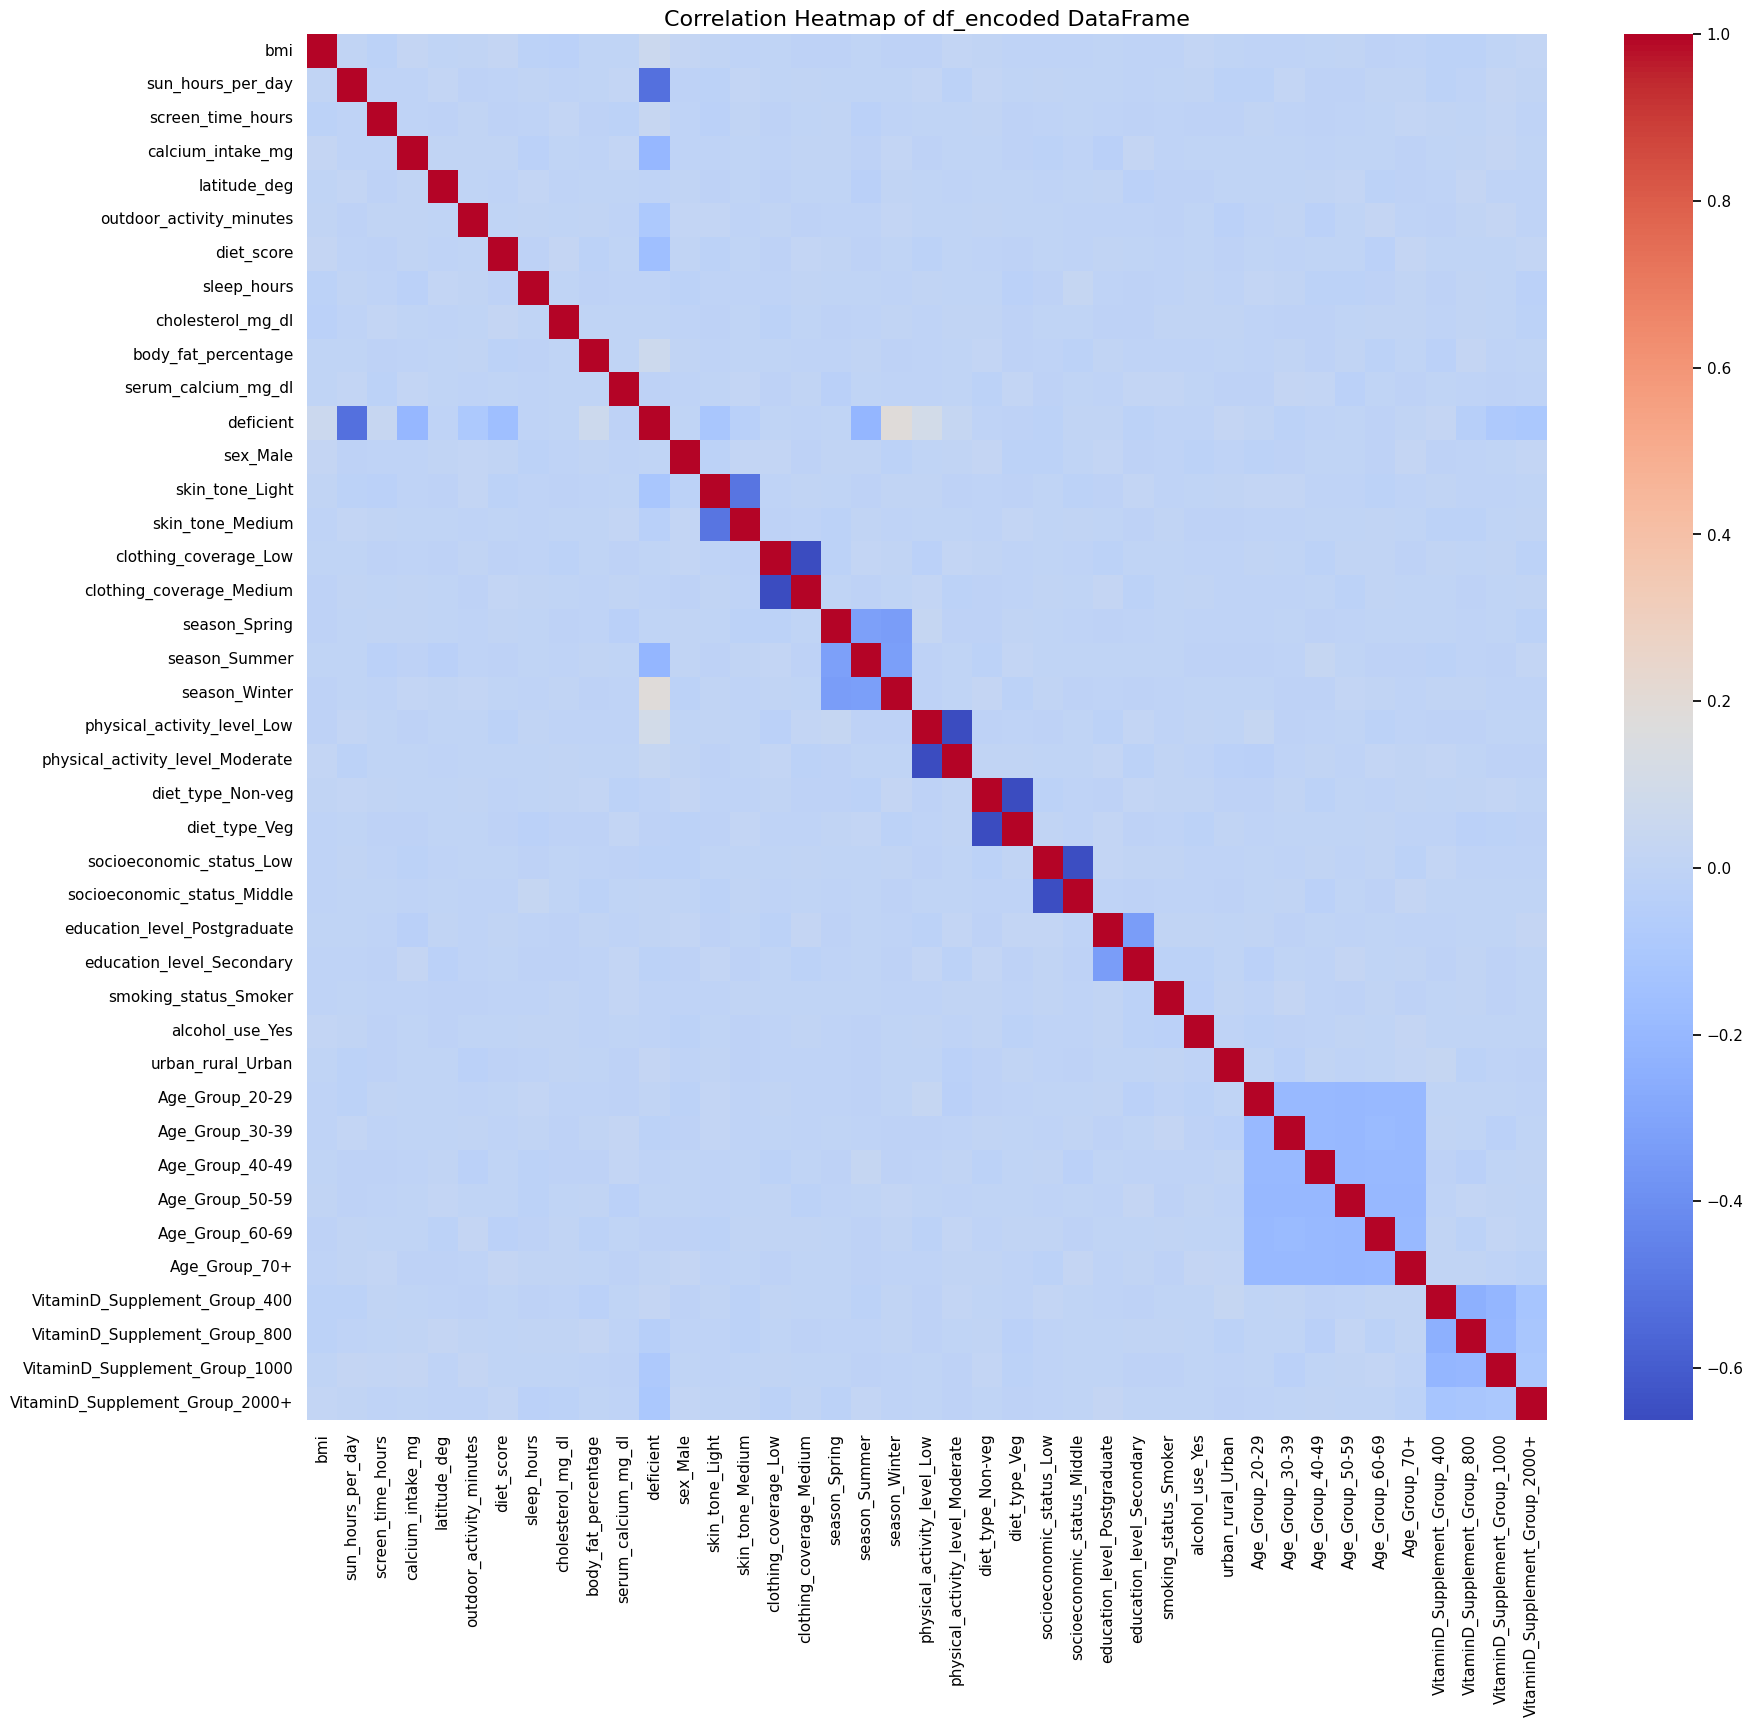

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure df and related variables are available for df_encoded creation if not already
# This re-runs parts of previous cells to ensure df_encoded is properly initialized
# in case it became None due to a previous error or skipped execution.
if 'df_encoded' not in globals() or df_encoded is None:
    # Assuming df is available and correctly preprocessed up to this point.
    # Re-create df['deficient'] as object type for get_dummies if necessary.
    # Check if 'deficient' column in df is already object to avoid unnecessary conversion.
    if 'df' in globals() and isinstance(df, pd.DataFrame):
        if 'deficient' in df.columns and df['deficient'].dtype != 'object':
            df['deficient'] = df['deficient'].astype('object')

        categorical_cols_to_encode = ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural']
        df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

        for col_bool in df_encoded.select_dtypes(include='bool').columns:
            df_encoded[col_bool] = df_encoded[col_bool].astype(int)

        # Re-create age and VitaminD_Supplement groups if they were dropped or not created on df
        # This assumes that df contains 'age' and 'vitamin_d_supplement_iu' if these groups are needed.
        if 'Age_Group' not in df.columns or 'VitaminD_Supplement_Group' not in df.columns:
            age_bins = [0, 20, 30, 40, 50, 60, 70, float('inf')]
            age_labels = ['Below 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
            delay_bins = [0, 400, 800, 1000, 2000, float('inf')]
            delay_labels = ['0', '400', '800', '1000', '2000+']
            # Ensure 'age' and 'vitamin_d_supplement_iu' are in df before creating groups
            if 'age' in df.columns:
                df['Age_Group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
            if 'vitamin_d_supplement_iu' in df.columns:
                df['VitaminD_Supplement_Group'] = pd.cut(df['vitamin_d_supplement_iu'], bins=delay_bins, labels=delay_labels, right=False)

        # Only proceed with concatenation if Age_Group and VitaminD_Supplement_Group were created
        if 'Age_Group' in df.columns and 'VitaminD_Supplement_Group' in df.columns:
            df_age_vitd_encoded = pd.get_dummies(df[['Age_Group', 'VitaminD_Supplement_Group']], drop_first=True)
            for col_bool in df_age_vitd_encoded.select_dtypes(include='bool').columns:
                df_age_vitd_encoded[col_bool] = df_age_vitd_encoded[col_bool].astype(int)
            df_encoded = pd.concat([df_encoded, df_age_vitd_encoded], axis=1)

        # Drop original age and vitamin_d_supplement_iu after creating groups
        # Check if they exist before dropping to avoid errors if they were already dropped
        if 'age' in df_encoded.columns:
            df_encoded = df_encoded.drop(columns=['age'])
        if 'vitamin_d_supplement_iu' in df_encoded.columns:
            df_encoded = df_encoded.drop(columns=['vitamin_d_supplement_iu'])
    else:
        # If df itself is not available, then we cannot proceed.
        raise RuntimeError("DataFrame 'df' is not defined. Cannot create df_encoded.")


plt.figure(figsize=(20, 18))
# Ensure 'deficient' column is numeric for correlation calculation
df_encoded['deficient'] = df_encoded['deficient'].astype(int)

# Drop non-numeric columns before calculating correlation
columns_to_drop_for_corr = ['supplement_tier', 'sun_hours_bins', 'sun_hours_quartile', 'sun_exposure_group']
df_numeric_for_corr = df_encoded.drop(columns=columns_to_drop_for_corr, errors='ignore')

sns.heatmap(df_numeric_for_corr.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Heatmap of df_encoded DataFrame', fontsize=16)
plt.show()

## 6. Train-Test Split for Deficiency Prediction

In [ ]:
# Split the encoded DataFrame
final_train, final_test = train_test_split(df_encoded, train_size=0.7, random_state=100)

# Check shapes
print("Train shape:", final_train.shape)
print("Test shape:", final_test.shape)

Train shape: (7000, 45)
Test shape: (3000, 45)


In [ ]:
df_encoded['deficient'] = df_encoded['deficient'].astype(int)

# Drop the 'deficient' target variable and the categorical columns created for visualizations
x = df_encoded.drop(columns=['deficient', 'supplement_tier', 'sun_hours_bins', 'sun_exposure_group', 'sun_hours_quartile'])
y = df_encoded['deficient']

In [ ]:
y.head()

,deficient
0,1
1,1
2,0
3,0
4,1


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.7, random_state=100, stratify=y
)

# Fit scaler on train only — then apply to both
scaler = StandardScaler()
x_train[columns_to_scale] = scaler.fit_transform(x_train[columns_to_scale])
x_test[columns_to_scale]  = scaler.transform(x_test[columns_to_scale])

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("Class balance in train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class balance in test: ", y_test.value_counts(normalize=True).round(3).to_dict())

X_train shape: (7000, 40)
X_test shape: (3000, 40)
Class balance in train: {0: 0.594, 1: 0.406}
Class balance in test:  {0: 0.594, 1: 0.406}


## 7. Model Training and Evaluation

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']

# Logistic Regression pipeline (scaler included so no leakage per fold)
pipe_lr = Pipeline(
    [('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]
)

# XGBoost (tree models don't need scaling but include for consistency)
pipe_xgb = Pipeline(
    [('model', XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, eval_metric='logloss'))]
)

# CatBoost
pipe_cat = Pipeline(
    [('model', CatBoostClassifier(iterations=300, learning_rate=0.1,
                                  depth=6, random_seed=42, verbose=0))]
)

results = {}
for name, pipe in [('Logistic Regression', pipe_lr),
                   ('XGBoost', pipe_xgb),
                   ('CatBoost', pipe_cat)]:
    cv_res = cross_validate(pipe, x, y, cv=cv, scoring=scoring)
    print(f"Intermediate cross-validation results for {name}: {cv_res.keys()}") # Added for debugging
    results[name] = {metric: f"{cv_res[f'test_{metric}'].mean():.3f} \u00b1 {cv_res[f'test_{metric}'].std():.3f}"
                     for metric in scoring}

cv_df = pd.DataFrame(results).T
print("\nCross-Validation Results (5-fold \u00d7 3 repeats):")
print(cv_df)

Intermediate cross-validation results for Logistic Regression: dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_roc_auc', 'test_f1', 'test_precision', 'test_recall'])
Intermediate cross-validation results for XGBoost: dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_roc_auc', 'test_f1', 'test_precision', 'test_recall'])
Intermediate cross-validation results for CatBoost: dict_keys(['fit_time', 'score_time', 'test_accuracy', 'test_roc_auc', 'test_f1', 'test_precision', 'test_recall'])

Cross-Validation Results (5-fold × 3 repeats):
                          accuracy        roc_auc             f1  \
Logistic Regression  0.850 ± 0.007  0.929 ± 0.005  0.813 ± 0.009   
XGBoost              0.839 ± 0.006  0.920 ± 0.005  0.797 ± 0.009   
CatBoost             0.840 ± 0.007  0.920 ± 0.006  0.799 ± 0.010   

                         precision         recall  
Logistic Regression  0.824 ± 0.010  0.801 ± 0.013  
XGBoost              0.815 ± 0.007  0.780 ± 0.014  
CatBoost    

In [ ]:
# calculating the deficient rate

deficient = sum(df_encoded['deficient'])/len(df_encoded['deficient'].index)
deficient

0.4056

Building the first model

### 7.1 Logistic Regression Model

In [ ]:
print(x_train.dtypes)

bmi                                 float64
sun_hours_per_day                   float64
screen_time_hours                   float64
calcium_intake_mg                   float64
latitude_deg                        float64
outdoor_activity_minutes            float64
diet_score                          float64
sleep_hours                         float64
cholesterol_mg_dl                   float64
body_fat_percentage                 float64
serum_calcium_mg_dl                 float64
sex_Male                              int64
skin_tone_Light                       int64
skin_tone_Medium                      int64
clothing_coverage_Low                 int64
clothing_coverage_Medium              int64
season_Spring                         int64
season_Summer                         int64
season_Winter                         int64
physical_activity_level_Low           int64
physical_activity_level_Moderate      int64
diet_type_Non-veg                     int64
diet_type_Veg                   

In [ ]:
# Ensure y_train is of integer type
y_train = y_train.astype(int)

# Ensure x_train is fully numeric (e.g., float) for statsmodels
x_train_converted = x_train.astype(float)

model = sm.GLM(y_train, (sm.add_constant(x_train_converted)), family = sm.families.Binomial())
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              deficient   No. Observations:                 7000
Model:                            GLM   Df Residuals:                     6959
Model Family:                Binomial   Df Model:                           40
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2268.5
Date:                Tue, 12 May 2026   Deviance:                       4536.9
Time:                        19:13:27   Pearson chi2:                 5.93e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5045
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.6475      0.291     -2.225      0.026      -1.218      -0.077
bmi                                  0.3839      0.039      9.947      0.000       0.308       0.459
sun_hours_per_day                   -2.2748      0.058    -38.898      0.000      -2.389      -2.160
screen_time_hours                    0.1248      0.038      3.317      0.001       0.051       0.199
calcium_intake_mg                   -0.9731      0.043    -22.691      0.000      -1.057      -0.889
latitude_deg                         0.0117      0.038      0.311      0.756      -0.062       0.085
outdoor_activity_minutes            -0.4487      0.039    -11.558      0.000      -0.525      -0.373
diet_score                          -0.7388      0.040    -18.270      0.000      -0.818      -0.659
sleep_hours                         -0.0605      0.038     -1.598      0.110      -0.135       0.014
cholesterol_mg_dl                   -0.0470      0.038     -1.248      0.212      -0.121       0.027
body_fat_percentage                  0.3498      0.038      9.189      0.000       0.275       0.424
serum_calcium_mg_dl                  0.0224      0.038      0.590      0.555      -0.052       0.097
sex_Male                             0.0422      0.075      0.560      0.575      -0.105       0.190
skin_tone_Light                     -2.1503      0.118    -18.163      0.000      -2.382      -1.918
skin_tone_Medium                    -1.0945      0.088    -12.493      0.000      -1.266      -0.923
clothing_coverage_Low                0.1001      0.109      0.921      0.357      -0.113       0.313
clothing_coverage_Medium             0.1697      0.100      1.694      0.090      -0.027       0.366
season_Spring                       -0.0629      0.102     -0.617      0.537      -0.262       0.137
season_Summer                       -2.0354      0.119    -17.090      0.000      -2.269      -1.802
season_Winter                        1.4303      0.106     13.457      0.000       1.222       1.639
physical_activity_level_Low          2.2325      0.122     18.320      0.000       1.994       2.471
physical_activity_level_Moderate     1.6271      0.110     14.790      0.000       1.411       1.843
diet_type_Non-veg                   -0.0570      0.104     -0.547      0.584      -0.261       0.147
diet_type_Veg                       -0.0739      0.100     -0.741      0.459      -0.269       0.121
socioeconomic_status_Low            -0.0829      0.109     -0.760      0.447      -0.297       0.131
socioeconomic_status_Middle          0.0278      0.100      0.278      0.781      -0.168       0.224
education_level_Postgraduate        -0.0336      0.092     -0.365      0.715      -0.214       0.147
education_level_Secondary           -0.1299      0.09

The Generalized Linear Model (GLM) is used with a Binomial family and Logit link function, suitable for binary classification. `sm.add_constant(x_train_converted)` adds an intercept term to the features. The model is then fitted and its summary is displayed, providing insights into coefficients, p-values, and overall model statistics.

#### 7.1.1. Feature Selection using RFE

In [ ]:
# Define the model (logistic regression)
logreg = LogisticRegression()

# Initialize RFE with the model and the number of features to select
rfe = RFE(estimator=logreg, n_features_to_select=15)

# Fit the RFE model
rfe = rfe.fit(x_train, y_train)


# creating a list of all the variables and their RFE rankings

list(zip(x_train.columns, rfe.support_, rfe.ranking_))




[('bmi', np.True_, np.int64(1)),
 ('sun_hours_per_day', np.True_, np.int64(1)),
 ('screen_time_hours', np.False_, np.int64(7)),
 ('calcium_intake_mg', np.True_, np.int64(1)),
 ('latitude_deg', np.False_, np.int64(26)),
 ('outdoor_activity_minutes', np.True_, np.int64(1)),
 ('diet_score', np.True_, np.int64(1)),
 ('sleep_hours', np.False_, np.int64(15)),
 ('cholesterol_mg_dl', np.False_, np.int64(18)),
 ('body_fat_percentage', np.False_, np.int64(2)),
 ('serum_calcium_mg_dl', np.False_, np.int64(25)),
 ('sex_Male', np.False_, np.int64(19)),
 ('skin_tone_Light', np.True_, np.int64(1)),
 ('skin_tone_Medium', np.True_, np.int64(1)),
 ('clothing_coverage_Low', np.False_, np.int64(12)),
 ('clothing_coverage_Medium', np.False_, np.int64(10)),
 ('season_Spring', np.False_, np.int64(14)),
 ('season_Summer', np.True_, np.int64(1)),
 ('season_Winter', np.True_, np.int64(1)),
 ('physical_activity_level_Low', np.True_, np.int64(1)),
 ('physical_activity_level_Moderate', np.True_, np.int64(1)),
 ('d

In [ ]:
# storing the selected columns in col

col = x_train.columns[rfe.support_]

In [ ]:
x_train[col].head()

,bmi,sun_hours_per_day,calcium_intake_mg,outdoor_activity_minutes,diet_score,skin_tone_Light,skin_tone_Medium,season_Summer,season_Winter,physical_activity_level_Low,physical_activity_level_Moderate,VitaminD_Supplement_Group_400,VitaminD_Supplement_Group_800,VitaminD_Supplement_Group_1000,VitaminD_Supplement_Group_2000+
900,-0.633298,1.365025,0.328598,-1.006633,-0.520656,0,1,0,0,0,1,0,0,0,0
3991,-0.181400,-0.675252,-0.287439,-0.975957,0.023299,0,0,0,0,0,1,0,0,0,1
3641,1.043122,0.709889,1.361600,-0.390512,-0.541870,1,0,0,1,0,0,1,0,0,0
2952,1.343665,1.318643,-0.972350,0.527559,0.275506,0,0,0,1,0,1,0,1,0,0
3882,-0.559985,-0.268558,-0.906113,-0.400773,-0.831719,1,0,0,0,1,0,1,0,0,0


#### 7.1.2. Building the Model Based on Selected Features

In [ ]:
# creating the model again

x_train_sm = sm.add_constant(x_train[col])
model_one = sm.GLM(y_train, x_train_sm, family = sm.families.Binomial())
pred = model_one.fit()
pred.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              deficient   No. Observations:                 7000
Model:                            GLM   Df Residuals:                     6984
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2329.8
Date:                Tue, 12 May 2026   Deviance:                       4659.6
Time:                        19:13:28   Pearson chi2:                 5.92e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4958
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.6114      0.118     -5.170      0.000      -0.843      -0.380
bmi                                  0.3884      0.038     10.188      0.000       0.314       0.463
sun_hours_per_day                   -2.2085      0.056    -39.105      0.000      -2.319      -2.098
calcium_intake_mg                   -0.9505      0.042    -22.616      0.000      -1.033      -0.868
outdoor_activity_minutes            -0.4337      0.038    -11.403      0.000      -0.508      -0.359
diet_score                          -0.7234      0.040    -18.210      0.000      -0.801      -0.646
skin_tone_Light                     -2.0790      0.116    -17.952      0.000      -2.306      -1.852
skin_tone_Medium                    -1.0440      0.086    -12.155      0.000      -1.212      -0.876
season_Summer                       -1.9795      0.105    -18.770      0.000      -2.186      -1.773
season_Winter                        1.4093      0.091     15.452      0.000       1.231       1.588
physical_activity_level_Low          2.1752      0.119     18.281      0.000       1.942       2.408
physical_activity_level_Moderate     1.5837      0.108     14.663      0.000       1.372       1.795
VitaminD_Supplement_Group_400       -0.6104      0.100     -6.123      0.000      -0.806      -0.415
VitaminD_Supplement_Group_800       -1.0552      0.105    -10.091      0.000      -1.260      -0.850
VitaminD_Supplement_Group_1000      -1.3894      0.116    -11.937      0.000      -1.618      -1.161
VitaminD_Supplement_Group_2000+     -2.6126      0.202    -12.932      0.000      -3.009      -2.217
====================================================================================================
"""

In [ ]:
# creating a new dataframe that consists of the name of the variables and their respective VIF

vif = pd.DataFrame()

# assigning the column 'variables' with the columns of X_train

vif['variables'] = x_train[col].columns

# assigning the column 'VIF' with the VIF values of the variales

vif['VIF'] = [variance_inflation_factor(x_train[col].values,i) for i in range (x_train[col].shape[1])]

# rounding off the VIF values to 2 decimal places

vif['VIF'] = round(vif['VIF'],2)

# sorting the VIF values in descending order

vif = vif.sort_values(by = 'VIF' , ascending = False)

# printing the dataframe vif

vif

,variables,VIF
10,physical_activity_level_Moderate,2.23
6,skin_tone_Medium,2.08
9,physical_activity_level_Low,1.74
5,skin_tone_Light,1.46
8,season_Winter,1.40
7,season_Summer,1.38
11,VitaminD_Supplement_Group_400,1.36
12,VitaminD_Supplement_Group_800,1.33
13,VitaminD_Supplement_Group_1000,1.28
14,VitaminD_Supplement_Group_2000+,1.10


In [ ]:
# Getting the predicted values on the train set

y_train_pred = pred.predict(x_train_sm)
y_train_pred[:20]

,0
900,0.055658
3991,0.613069
3641,0.022161
2952,0.361736
3882,0.708229
3714,0.750296
4969,0.970058
3259,0.968923
1485,0.963940
2363,0.000649


In [ ]:
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred[:20]

array([5.56579544e-02, 6.13068794e-01, 2.21607247e-02, 3.61736048e-01,
       7.08228539e-01, 7.50296181e-01, 9.70058187e-01, 9.68922657e-01,
       9.63940315e-01, 6.48825612e-04, 9.11574614e-02, 9.87984870e-01,
       2.21438882e-01, 4.21388585e-01, 8.46863180e-01, 8.28173238e-02,
       3.67791564e-02, 9.42471231e-02, 3.51358758e-02, 9.85087844e-01])

In [ ]:
y_train_pred_final = pd.DataFrame({'Actual': y_train, 'Predicted_Prob': y_train_pred})
y_train_pred_final.head()


,Actual,Predicted_Prob
900,0,0.055658
3991,0,0.613069
3641,0,0.022161
2952,1,0.361736
3882,0,0.708229


In [ ]:
OPTIMAL_THRESHOLD = 0.4  # determined from cutoff analysis in Cell 70

y_train_pred_final['Predicted'] = y_train_pred_final['Predicted_Prob'].apply(
    lambda x: 1 if x > OPTIMAL_THRESHOLD else 0
)

In [ ]:
y_train_pred_final.head()

,Actual,Predicted_Prob,Predicted
900,0,0.055658,0
3991,0,0.613069,1
3641,0,0.022161,0
2952,1,0.361736,0
3882,0,0.708229,1


## 8. Evaluating the Logistic Regression Model

In [ ]:
import sklearn.metrics as metrics
print(metrics.accuracy_score(y_train_pred_final.Actual, y_train_pred_final.Predicted))

0.845


#### 10.2. Fitting the XGBoost Model

The `metrics.accuracy_score` function computes the proportion of correctly classified instances by comparing the actual labels (`y_train_pred_final.Actual`) with the predicted labels (`y_train_pred_final.Predicted`) on the training set.

In [ ]:
# creating the confusion matrix

confusion = metrics.confusion_matrix(y_train_pred_final.Actual, y_train_pred_final.Predicted)
print(confusion)

[[3492  669]
 [ 416 2423]]


The `metrics.confusion_matrix` function generates a confusion matrix, which is a table used to describe the performance of a classification model. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

In [ ]:
# true positives
tp = confusion[1,1]

#true negatives
tn = confusion[0,0]

# false positives
fp = confusion[0,1]

# false negatives
fn = confusion[1,0]

In [ ]:
# sensitivity of the model : A measure of how accurately does the model predict the positive outcomes
# sesitivity can also be termed as true positive rate

tp /(tp+fn)

np.float64(0.8534695315251849)

Sensitivity (True Positive Rate) measures the proportion of actual positive cases that are correctly identified as positive by the model. A higher sensitivity means fewer false negatives.

In [ ]:
# specificity of the model : A measure of how accurately does the model predict negative outcomes

tn /(tn+fp)

np.float64(0.8392213410237923)

Specificity (True Negative Rate) measures the proportion of actual negative cases that are correctly identified as negative by the model. A higher specificity means fewer false positives.

In [ ]:
f1 = 2 * (tp / (tp + fn)) * (tp / (tp + fp)) / ((tp / (tp + fn)) + (tp / (tp + fp)))
f1

np.float64(0.8170628899005227)

The F1-score is the harmonic mean of precision and recall. It's a useful metric when you need to seek a balance between precision and recall, especially in cases of imbalanced classes.

In [ ]:
# false positive rate : A measure of how many 0s were predicted as 1

fp /(tn+fp)

np.float64(0.16077865897620763)

False Positive Rate (FPR) measures the proportion of actual negative cases that are incorrectly identified as positive by the model. It's calculated as (False Positives) / (True Negatives + False Positives).

#### 8.1. ROC Curve

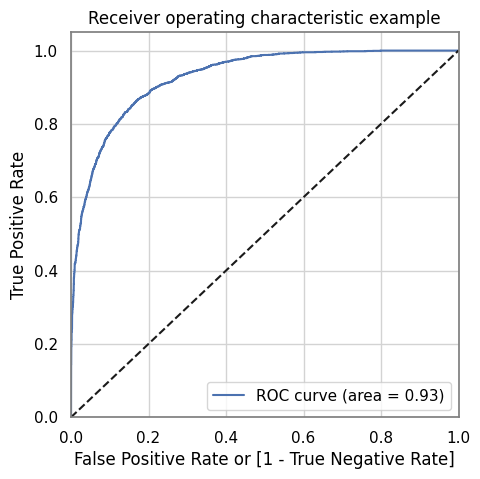

In [ ]:
# preparing the ROC curve

def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs, drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

# Calling the function
draw_roc(y_train_pred_final.Actual, y_train_pred_final.Predicted_Prob)

In [ ]:
# checking different probablity cutoffs

numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i] = y_train_pred_final.Predicted_Prob.map(lambda x:1 if x>i else 0)
y_train_pred_final.head()

,Actual,Predicted_Prob,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
900,0,0.055658,0,1,0,0,0,0,0,0,0,0,0
3991,0,0.613069,1,1,1,1,1,1,1,1,0,0,0
3641,0,0.022161,0,1,0,0,0,0,0,0,0,0,0
2952,1,0.361736,0,1,1,1,1,0,0,0,0,0,0
3882,0,0.708229,1,1,1,1,1,1,1,1,1,0,0


In [ ]:
# creating a dataframe with information about probability, accuracy, sensitivity and specificity

cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
#from sklearn.metrics import confusion_matrix

# tp = confusion[1,1]  true positive
# tn = confusion[0,0]  true negatives
# fp = confusion[0,1]  false positives
# fn = confusion[1,0]  false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Actual, y_train_pred_final[i])
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1

    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])

    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]

print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.405571  1.000000  0.000000
0.1   0.1  0.731857  0.976400  0.565008
0.2   0.2  0.795429  0.939415  0.697188
0.3   0.3  0.828857  0.899613  0.780582
0.4   0.4  0.845000  0.853470  0.839221
0.5   0.5  0.849143  0.800634  0.882240
0.6   0.6  0.845571  0.742867  0.915645
0.7   0.7  0.830286  0.660444  0.946167
0.8   0.8  0.804286  0.560761  0.970440
0.9   0.9  0.754429  0.408595  0.990387


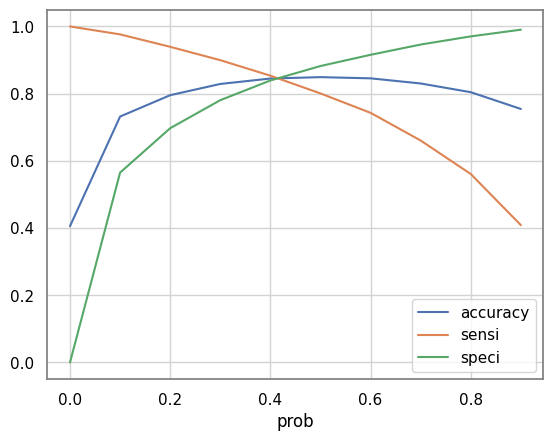

In [ ]:
# plotting probability

cutoff_df.plot.line(x= 'prob', y = ['accuracy','sensi','speci'])
plt.show()

## 9. Testing the Model on Test Set

In [ ]:
final_test.head()

,bmi,sun_hours_per_day,screen_time_hours,calcium_intake_mg,latitude_deg,outdoor_activity_minutes,diet_score,sleep_hours,cholesterol_mg_dl,body_fat_percentage,...,Age_Group_20-29,Age_Group_30-39,Age_Group_40-49,Age_Group_50-59,Age_Group_60-69,Age_Group_70+,VitaminD_Supplement_Group_400,VitaminD_Supplement_Group_800,VitaminD_Supplement_Group_1000,VitaminD_Supplement_Group_2000+
8018,22.742910,6.570913,3.279894,488.059258,30.495587,68.086021,5.467769,3.219830,135.532772,25.231704,...,0,1,0,0,0,0,0,0,0,0
9225,30.346284,0.652985,3.410380,504.900748,22.507703,64.366174,5.391860,6.150132,141.857325,19.072903,...,0,0,0,1,0,0,0,0,0,0
3854,27.140282,6.160200,1.464447,959.657622,14.513601,81.472868,8.152626,6.199578,190.870437,19.120101,...,1,0,0,0,0,0,1,0,0,0
2029,23.095026,5.915929,1.178848,629.913184,29.569663,121.218707,7.236067,10.000000,156.575626,23.513236,...,1,0,0,0,0,0,0,0,0,1
3539,26.245262,1.880333,9.621932,300.000000,35.563344,15.491290,5.463282,5.826309,123.343813,23.255607,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
# Get the common columns between 'col' and 'x_test'
common_cols = list(set(col) & set(x_test.columns))

# Select only the common columns from 'x_test'
x_test = x_test[common_cols]

In [ ]:
x_test.head()

,VitaminD_Supplement_Group_400,outdoor_activity_minutes,VitaminD_Supplement_Group_1000,season_Winter,calcium_intake_mg,diet_score,skin_tone_Medium,bmi,VitaminD_Supplement_Group_2000+,physical_activity_level_Moderate,VitaminD_Supplement_Group_800,skin_tone_Light,sun_hours_per_day,season_Summer,physical_activity_level_Low
4356,1,-0.405495,0,1,0.364821,-1.226967,1,0.960752,0,1,0,0,-1.577139,0,0
1429,0,-1.233743,0,1,-1.561334,0.670341,1,2.966489,0,1,0,0,0.117820,0,0
7294,0,-0.122249,1,0,-0.843226,-1.825232,1,2.609731,0,0,0,0,0.520242,0,1
3124,0,-0.543263,0,0,0.922276,-0.228396,1,-2.026323,0,0,0,0,-0.917202,1,0
309,1,0.807605,0,0,-0.462773,-0.366846,1,0.130069,0,0,0,0,1.435941,0,1


In [ ]:
# adding the constant to x_test

x_test_sm = sm.add_constant(x_test)

In [ ]:
# creating the predictions based on the model

y_test_pred = pred.predict(x_test_sm)
y_test_pred[:20]

,0
4356,0.968304
1429,0.030775
7294,0.001910
3124,0.949864
309,0.001764
4763,0.299817
5586,0.601376
8071,0.058173
6822,0.015731
290,0.927412


In [ ]:
# Ensure x_test has the exact same columns as the training set (including constant)
missing_cols = list(set(col) - set(x_test.columns))

# Add any missing columns with 0s
for c in missing_cols:
    x_test[c] = 0

# Reorder columns to match training set order
x_test = x_test[col]

# Add constant
x_test_sm = sm.add_constant(x_test)

# Step 3: Predict
y_test_pred = pred.predict(x_test_sm)

# Step 4: Preview predictions
y_test_pred[:20]


,0
4356,0.995034
1429,0.977331
7294,0.763146
3124,0.053557
309,0.054354
4763,0.092220
5586,0.086976
8071,0.039478
6822,0.629094
290,0.093027


In [ ]:
# creating different columns to store the covert situation and the probability for the same

y_test_final = pd.DataFrame({'Actual' : y_test.values, 'Predicted_Prob' : y_test_pred})

In [ ]:
y_test_final.head()

,Actual,Predicted_Prob
4356,1,0.995034
1429,1,0.977331
7294,1,0.763146
3124,0,0.053557
309,0,0.054354


In [ ]:
# Apply the same optimal threshold as used on training set
y_test_final['Predicted'] = y_test_final.Predicted_Prob.map(
    lambda x: 1 if x > OPTIMAL_THRESHOLD else 0
)

In [ ]:
# the accuracy of the model

print(metrics.accuracy_score(y_test_final.Actual, y_test_final.Predicted))

0.838


In [ ]:
# creating the confusion matrix

confusion_one = metrics.confusion_matrix(y_test_final.Actual, y_test_final.Predicted)
print(confusion_one)

[[1481  302]
 [ 184 1033]]


In [ ]:
# true positives
tp1 = confusion_one[1,1]

#true negatives
tn1 = confusion_one[0,0]

# false positives
fp1 = confusion_one[0,1]

# false negatives
fn1 = confusion_one[1,0]

In [ ]:
# sensitivity of the model : A measure of how accurately does the model predict the positive outcomes
# sesitivity can also be termed as true positive rate

tp1 /(tp1+fn1)

np.float64(0.8488085456039441)

In [ ]:
# specificity of the model : A measure of how accurately does the model predict negative outcomes

tn1 /(tn1+fp1)

np.float64(0.8306225462703309)

In [ ]:
f1 = 2 * (tp1 / (tp1 + fn1)) * (tp1 / (tp1 + fp1)) / ((tp1 / (tp1 + fn1)) + (tp1 / (tp1 + fp1)))
f1

np.float64(0.8095611285266457)

In [ ]:
# false positive rate : A measure of how many 0s were predicted as 1

fp1 /(tn1+fp1)

np.float64(0.1693774537296691)

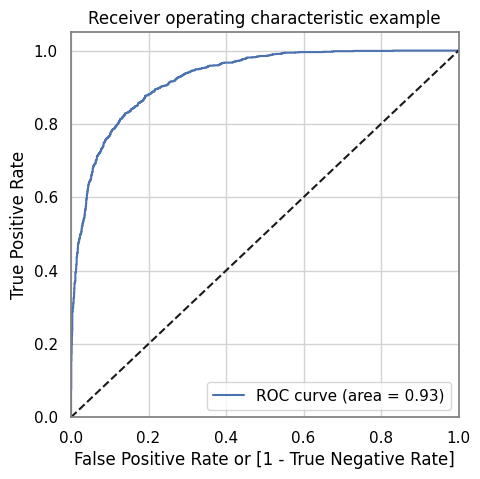

In [ ]:
# preparing the ROC curve

def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs, drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

# Calling the function
draw_roc(y_test_final.Actual, y_test_final.Predicted_Prob)

## 10. XGBoost Model Training and Evaluation

In [ ]:
# 2. ALIGN test set to training set (CRITICAL FIX)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [ ]:
# Optional sanity check
print((x_train.columns == x_test.columns).all())  # should be True

True


#### 10.1. Initializing the XGBoost Model

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
}

xgb_base = XGBClassifier(
    colsample_bytree=0.8, random_state=42, eval_metric='logloss'
)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(x_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV AUC:", round(grid_search.best_score_, 4))

xgb_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV AUC: 0.9223


This code defines a parameter grid for hyperparameter tuning of the XGBoost classifier using `GridSearchCV`. `xgb_base` is initialized with common parameters, and `grid_search` is configured to perform 5-fold cross-validation, optimizing for ROC AUC. After fitting, it prints the best parameters found and the corresponding AUC score, then assigns the best estimator to `xgb_model`.

Fit the model

In [ ]:
xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

The `xgb_model` is trained on the preprocessed training data (`x_train`, `y_train`). This step fits the XGBoost model to learn the relationships between features and the target variable.

#### 10.3. XGBoost Predictions and Evaluation

In [ ]:
y_pred = xgb_model.predict(x_test)
y_prob = xgb_model.predict_proba(x_test)[:, 1]

After training, the model makes predictions on the test set (`x_test`). `y_pred` stores the binary class predictions (0 or 1), while `y_prob` stores the predicted probabilities for the positive class (class 1), which are essential for ROC-AUC calculation.

In [ ]:
# 6. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.8413333333333334
ROC-AUC: 0.9209686480228914
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1783
           1       0.84      0.76      0.79      1217

    accuracy                           0.84      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.84      0.84      0.84      3000



This section evaluates the performance of the trained XGBoost model on the test set using several metrics: accuracy, ROC-AUC, and a detailed classification report including precision, recall, and F1-score for each class.

## 11. CatBoost Model Training and Evaluation

In [ ]:
cat_model = CatBoostClassifier(
    iterations=300, learning_rate=0.1, depth=6, random_seed=42, verbose=0, eval_metric='AUC'
)
cat_model.fit(x_train, y_train, eval_set=(x_test, y_test), early_stopping_rounds=50, use_best_model=True)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.1, random_seed=42, verbose=0)

The CatBoost classifier is initialized with specific hyperparameters such as `iterations` (number of boosting rounds), `learning_rate`, `depth` of trees, `eval_metric` (AUC for evaluation), `early_stopping_rounds` to prevent overfitting, and `random_seed` for reproducibility. `verbose=100` prints training progress every 100 iterations.

The CatBoost model is trained using the training data (`x_train`, `y_train`). `eval_set` is provided with the test data to monitor performance and enable early stopping. `use_best_model=True` ensures that the final model is the one that performed best on the evaluation set during training, effectively preventing overfitting.

In [ ]:
#### 11.1. CatBoost Predictions and Evaluation

In [ ]:
y_pred_cat = cat_model.predict(x_test)
y_prob_cat = cat_model.predict_proba(x_test)[:, 1]

After training, the CatBoost model generates predictions on the test set. `y_pred_cat` contains the binary class predictions, and `y_prob_cat` stores the predicted probabilities for the positive class, which are used for advanced evaluation metrics like ROC-AUC.

In [ ]:
# 5. Evaluation
print("CatBoost Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cat))
print(classification_report(y_test, y_pred_cat))

CatBoost Model Performance on Test Set:
Accuracy: 0.8476666666666667
ROC-AUC: 0.9217889581646436
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1783
           1       0.83      0.78      0.81      1217

    accuracy                           0.85      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.85      0.85      0.85      3000



This section displays the performance metrics for the CatBoost model on the test set, including accuracy, ROC-AUC score, and a comprehensive classification report that provides precision, recall, and F1-score for both classes.

## 12. TabNet Model Training and Evaluation

In [ ]:
tabnet_model = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.3, n_independent=2, n_shared=2,
    optimizer_fn=torch.optim.Adam, optimizer_params=dict(lr=1e-2),
    scheduler_params={"step_size": 30, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, mask_type='sparsemax',
    seed=42, verbose=0
)
tabnet_model.fit(
    X_train=x_train.values, y_train=y_train.values,
    eval_set=[(x_test.values, y_test.values)],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=50, patience=10, batch_size=256, virtual_batch_size=128
)


Early stopping occurred at epoch 33 with best_epoch = 23 and best_test_auc = 0.90976


The TabNetClassifier is initialized with parameters that control the network architecture and training process. `n_d` and `n_a` specify the dimension of the attention and feature transformers, `n_steps` is the number of decision steps, `gamma` controls the sparsity of feature selection, `optimizer_fn` and `optimizer_params` configure the optimizer, and `scheduler_params` define the learning rate scheduler. `mask_type='sparsemax'` encourages sparse feature selection, and `seed` ensures reproducibility.

In [ ]:
#### 12.1. Fitting the TabNet Model

# 3. Fit the model
tabnet_model.fit(
    X_train=x_train.values,  # convert to numpy arrays
    y_train=y_train.values,
    eval_set=[(x_test.values, y_test.values)],
    eval_name=['test'],
    eval_metric=['auc'],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=128
)


Early stopping occurred at epoch 43 with best_epoch = 23 and best_test_auc = 0.90976


The TabNet model is trained using the training data (`x_train`, `y_train`). `eval_set` specifies the test data for evaluation during training, with 'auc' as the evaluation metric. `max_epochs` sets the maximum number of training epochs, and `patience` implements early stopping if the evaluation metric does not improve for a specified number of epochs. `batch_size` and `virtual_batch_size` configure the mini-batch sizes for training.

In [ ]:
#### 12.2. TabNet Predictions and Evaluation
# 4. Predictions
y_pred_tab = tabnet_model.predict(x_test.values)
y_prob_tab = tabnet_model.predict_proba(x_test.values)[:,1]

# 5. Evaluation
print("TabNet Model Performance on Test Set:")
print("Accuracy:", accuracy_score(y_test, y_pred_tab))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tab))
print(classification_report(y_test, y_pred_tab))

TabNet Model Performance on Test Set:
Accuracy: 0.8296666666666667
ROC-AUC: 0.9097626584684809
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1783
           1       0.78      0.81      0.79      1217

    accuracy                           0.83      3000
   macro avg       0.82      0.83      0.82      3000
weighted avg       0.83      0.83      0.83      3000



After fitting, the TabNet model makes predictions on the test set. `y_pred_tab` stores the binary class predictions, and `y_prob_tab` stores the predicted probabilities for the positive class. These predictions are then used to evaluate the model's performance on the test set, reporting accuracy, ROC-AUC, and a classification report.

## 13. Model Comparison

This helper function calculates and returns a dictionary of common classification metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC) for a given set of true labels, predicted labels, and predicted probabilities.

In [ ]:
# --- Helper function to compute metrics ---
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

In [ ]:
import torch

# --- Logistic Regression ---
# --- Logistic Regression (uses OPTIMAL_THRESHOLD set in Cell 56) ---
y_prob_lr = y_test_final['Predicted_Prob']
y_test_pred_lr = (y_prob_lr > OPTIMAL_THRESHOLD).astype(int)

# --- XGBoost ---
y_pred_xgb = xgb_model.predict(x_test)
y_prob_xgb = xgb_model.predict_proba(x_test)[:, 1]

# --- CatBoost ---
y_pred_cat = cat_model.predict(x_test)
y_prob_cat = cat_model.predict_proba(x_test)[:, 1]

# --- TabNet ---
tabnet_model.fit(
    X_train=x_train.values, y_train=y_train.values,
    eval_set=[(x_test.values, y_test.values)],
    eval_name=['test'], eval_metric=['auc'],
    max_epochs=50, patience=10, batch_size=256, virtual_batch_size=128
)
y_pred_tab = tabnet_model.predict(x_test.values)  # tabnet expects numpy array
y_prob_tab = tabnet_model.predict_proba(x_test.values)[:, 1]


Early stopping occurred at epoch 33 with best_epoch = 23 and best_test_auc = 0.90976


This section generates predictions (both class labels and probabilities) for all trained models (Logistic Regression, XGBoost, CatBoost, and TabNet) using the test set. For Logistic Regression, it re-applies the `OPTIMAL_THRESHOLD` determined earlier. For XGBoost and CatBoost, it uses `predict` and `predict_proba`. For TabNet, it uses the numpy array representation of `x_test`.

In [ ]:
### 13.2. Model Comparison Table
# --- Model Comparison Table ---
model_comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', **get_metrics(y_test, y_test_pred_lr, y_prob_lr)},
    {'Model': 'XGBoost', **get_metrics(y_test, y_pred_xgb, y_prob_xgb)},
    {'Model': 'CatBoost', **get_metrics(y_test, y_pred_cat, y_prob_cat)},
    {'Model': 'TabNet', **get_metrics(y_test, y_pred_tab, y_prob_tab)}
])

print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.838000   0.773783  0.848809  0.809561  0.925881
1              XGBoost  0.841333   0.837125  0.755957  0.794473  0.920969
2             CatBoost  0.847667   0.831010  0.783895  0.806765  0.921789
3               TabNet  0.829667   0.781051  0.806081  0.793368  0.909763


This code creates a pandas DataFrame to compile and display the performance metrics for all individual models (Logistic Regression, XGBoost, CatBoost, and TabNet) on the test set. It uses the `get_metrics` helper function to calculate metrics for each model and then presents them in a comparative table.

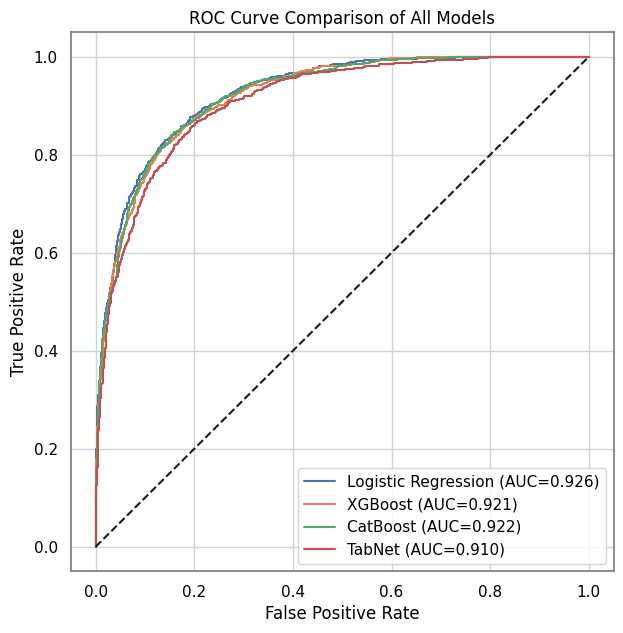

In [ ]:
### 13.3. ROC Curves Comparison

# --- ROC Curves Comparison ---
plt.figure(figsize=(7, 7))

# Logistic
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')

# XGBoost
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr, tpr, label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})')

# CatBoost
fpr, tpr, _ = roc_curve(y_test, y_prob_cat)
plt.plot(fpr, tpr, label=f'CatBoost (AUC={roc_auc_score(y_test, y_prob_cat):.3f})')

# TabNet
fpr, tpr, _ = roc_curve(y_test, y_prob_tab)
plt.plot(fpr, tpr, label=f'TabNet (AUC={roc_auc_score(y_test, y_prob_tab):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of All Models')
plt.legend(loc='lower right')
plt.show()

This code generates a comparative ROC curve plot for all trained models. It calculates the False Positive Rate (FPR) and True Positive Rate (TPR) for each model's predictions on the test set and then plots these curves along with their respective Area Under the Curve (AUC) scores. A diagonal dashed line represents a random classifier for reference.

## 14. Decision Curve Analysis

In [ ]:
def decision_curve(y_true, y_prob, thresholds):
    N = len(y_true)
    net_benefits = []

    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)

        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))

        net_benefit = (TP / N) - (FP / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)

    return net_benefits

This `decision_curve` function calculates net benefit for various probability thresholds. It iterates through given thresholds, predicts binary outcomes, computes True Positives (TP) and False Positives (FP), and then applies the net benefit formula: `(TP/N) - (FP/N) * (pt / (1-pt))`, where `pt` is the threshold probability. This helps evaluate the clinical utility of a model.

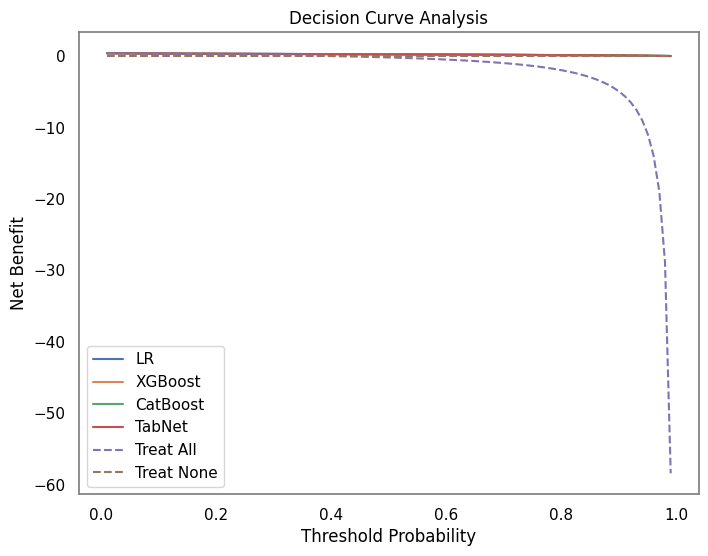

In [ ]:
thresholds = np.linspace(0.01, 0.99, 100)

# Models
nb_lr = decision_curve(y_test, y_prob_lr, thresholds)
nb_xgb = decision_curve(y_test, y_prob_xgb, thresholds)
nb_cat = decision_curve(y_test, y_prob_cat, thresholds)
nb_tab = decision_curve(y_test, y_prob_cat, thresholds)

# Baselines
prevalence = np.mean(y_test)
treat_all = [prevalence - (1 - prevalence) * (pt / (1 - pt)) for pt in thresholds]
treat_none = [0 for _ in thresholds]

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, nb_lr, label='LR')
plt.plot(thresholds, nb_xgb, label='XGBoost')
plt.plot(thresholds, nb_cat, label='CatBoost')
plt.plot(thresholds, nb_cat, label='TabNet')

plt.plot(thresholds, treat_all, linestyle='--', label='Treat All')
plt.plot(thresholds, treat_none, linestyle='--', label='Treat None')

plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis')
plt.legend()
plt.grid()
plt.show()

This code generates a Decision Curve Analysis (DCA) plot to compare the clinical utility of different models (Logistic Regression, XGBoost, CatBoost, and an ensemble) against baseline strategies ('Treat All' and 'Treat None'). It calculates the net benefit for a range of probability thresholds and visualizes how each model performs in terms of benefits versus harms of intervention.

## 15. SHAP Integration

This section utilizes SHAP (SHapley Additive exPlanations) to interpret the CATBOOST model's predictions. `shap.TreeExplainer` is used to create an explainer for tree-based models. `shap_values` are computed for the test set. Summary plots (bar and beeswarm) show overall feature importance and directional impact, while a force plot visualizes the contribution of each feature for a single prediction.

SHAP Summary Plot (Bar) for CatBoost:


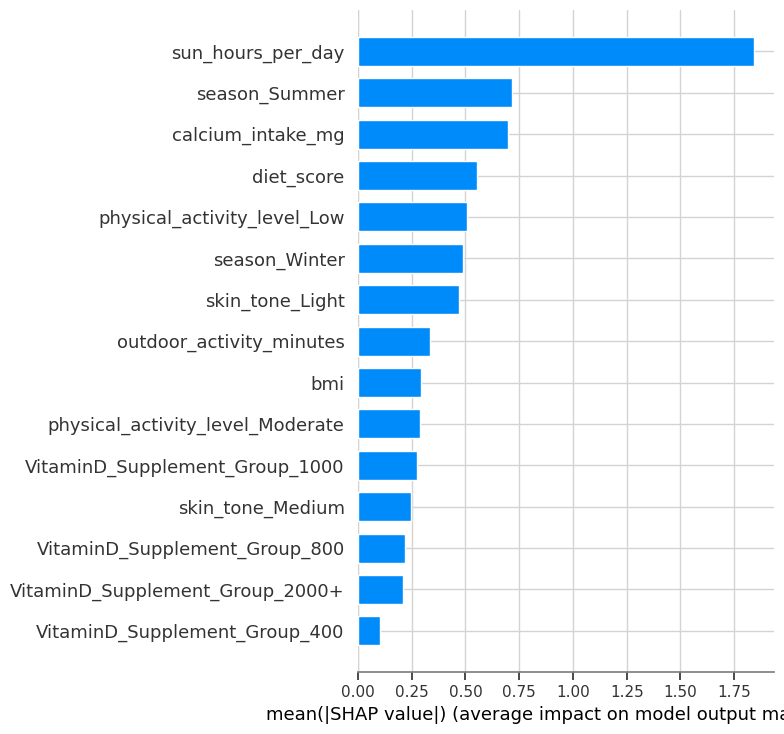

SHAP Summary Plot (Beeswarm) for CatBoost:


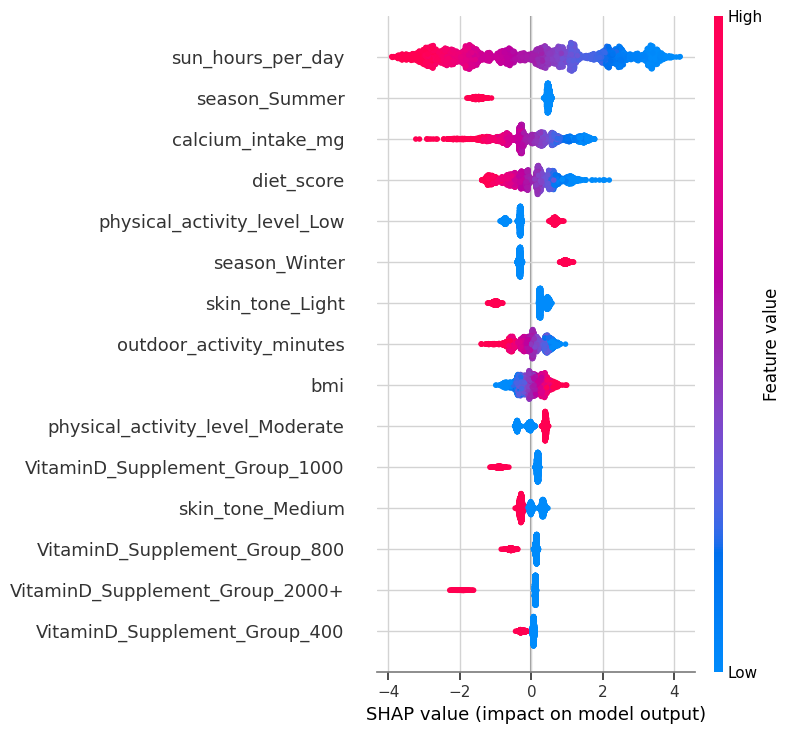

In [ ]:
# CatBoost uses TreeExplainer
explainer_cat = shap.TreeExplainer(cat_model)

# Compute SHAP values for the test set
shap_values_cat = explainer_cat.shap_values(x_test)

# Summary plot (bar)
print("SHAP Summary Plot (Bar) for CatBoost:")
shap.summary_plot(shap_values_cat, x_test, plot_type='bar', max_display=15)

# Summary plot (beeswarm)
print("SHAP Summary Plot (Beeswarm) for CatBoost:")
shap.summary_plot(shap_values_cat, x_test, max_display=15)

## 17. Save Models and Preprocessed Data for Streamlit

This section applies SHAP to interpret the Logistic Regression model. It extracts the coefficients and intercept from the fitted GLM model (`pred`) and uses `shap.LinearExplainer` for linear models. SHAP values are then computed for the RFE-selected features on the test set. Similar to the XGBoost interpretation, summary plots (bar and beeswarm) illustrate global feature importance, and a force plot explains a single prediction.

 ## 16. Streamlit

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

warnings.filterwarnings("ignore")

# --- 1. Decision Curve Analysis Function ---
def decision_curve(y_true, y_prob, thresholds):
    N = len(y_true)
    net_benefits = []
    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        if (1 - pt) == 0:
            net_benefit = TP / N
        else:
            net_benefit = (TP / N) - (FP / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)
    return net_benefits

# --- 2. Data Loading & Preprocessing ---
@st.cache_data
def load_and_preprocess_data():
    df = pd.read_csv('Vitamin_D_Dataset.csv')
    df.dropna(inplace=True)
    df.columns = [
        'age', 'bmi', 'sun_hours_per_day', 'screen_time_hours', 'calcium_intake_mg',
        'vitamin_d_supplement_iu', 'latitude_deg', 'outdoor_activity_minutes',
        'diet_score', 'sleep_hours', 'cholesterol_mg_dl', 'body_fat_percentage',
        'serum_calcium_mg_dl', 'sex', 'skin_tone', 'clothing_coverage', 'season',
        'physical_activity_level', 'diet_type', 'socioeconomic_status',
        'education_level', 'smoking_status', 'alcohol_use', 'urban_rural',
        'vitamin_d_ng_ml', 'deficient'
    ]
    df['sun_exposure_group'] = pd.cut(df['sun_hours_per_day'], bins=[0, 2, 4, 6, 8], labels=['Low', 'Moderate', 'High', 'V. High'])
    df['supplement_tier'] = pd.cut(df['vitamin_d_supplement_iu'], bins=[-1, 0, 400, 800, 1500, 10000], labels=['None', 'Low', 'Medium', 'High', 'V. High'], right=False)
    cat_cols = ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural']
    df_ml = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    df_ml['Age_Group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 60, 70, 120], labels=['<20', '20s', '30s', '40s', '50s', '60s', '70+'])
    df_ml['Supp_Group'] = pd.cut(df['vitamin_d_supplement_iu'], bins=[-1, 400, 800, 1000, 2000, 20000], labels=['0', '400', '800', '1000', '2000+'])
    df_ml = pd.get_dummies(df_ml, columns=['Age_Group', 'Supp_Group'], drop_first=True)
    for col in df_ml.select_dtypes(include='bool').columns:
        df_ml[col] = df_ml[col].astype(int)
    return df, df_ml

df_raw, df_ml = load_and_preprocess_data()
X = df_ml.drop(columns=['deficient', 'vitamin_d_ng_ml', 'age', 'vitamin_d_supplement_iu', 'sun_exposure_group', 'supplement_tier'], errors='ignore')
y = df_ml['deficient']
NUM_COLS = ['bmi', 'sun_hours_per_day', 'screen_time_hours', 'calcium_intake_mg', 'latitude_deg', 'outdoor_activity_minutes', 'diet_score', 'sleep_hours', 'cholesterol_mg_dl', 'body_fat_percentage', 'serum_calcium_mg_dl']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)
scaler = StandardScaler()
x_train_sc = x_train.copy(); x_test_sc = x_test.copy()
x_train_sc[NUM_COLS] = scaler.fit_transform(x_train[NUM_COLS])
x_test_sc[NUM_COLS] = scaler.transform(x_test[NUM_COLS])

@st.cache_resource
def train_models(_xt, _yt, _xv, _yv):
    cat = CatBoostClassifier(iterations=300, depth=6, verbose=0, random_seed=42).fit(_xt, _yt)
    xgb = XGBClassifier(random_state=42).fit(_xt, _yt)
    lr = LogisticRegression(max_iter=1000).fit(_xt, _yt)
    tab = TabNetClassifier(verbose=0, seed=42)
    tab.fit(X_train=_xt.values, y_train=_yt.values, eval_set=[(_xv.values, _yv.values)], max_epochs=20)
    return cat, xgb, lr, tab

cat_m, xgb_m, lr_m, tab_m = train_models(x_train_sc, y_train, x_test_sc, y_test)

st.set_page_config(page_title="Vitamin D Prediction Full Analysis", layout="wide")
st.title("🎓 Vitamin D Deficiency: Comprehensive Analysis Dashboard")
tab_eda, tab_eval, tab_clinical = st.tabs(["📊 Exploratory Data Analysis", "🧪 Model Performance", "🔮 Predictive Diagnostic"])

with tab_eda:
    st.header("Epidemiological Insights")
    c1, c2 = st.columns(2)
    with c1:
        st.subheader("1. Risk Surface (Sun vs. Supplementation)")
        risk = df_raw.groupby(['supplement_tier', 'sun_exposure_group'])['deficient'].mean().unstack().astype(float)
        fig, ax = plt.subplots(); sns.heatmap(risk*100, annot=True, cmap="RdYlGn_r", ax=ax); st.pyplot(fig); plt.close()
        st.subheader("2. Vitamin D Distribution")
        fig, ax = plt.subplots(); sns.violinplot(x='deficient', y='vitamin_d_ng_ml', data=df_raw, ax=ax); ax.axhline(20, color='gold', ls='--'); st.pyplot(fig); plt.close()
        st.subheader("3. Age KDE Profile")
        fig, ax = plt.subplots(); sns.kdeplot(data=df_raw, x='age', hue='deficient', fill=True, ax=ax); st.pyplot(fig); plt.close()
    with c2:
        st.subheader("4. Body Fat % vs. Vitamin D")
        fig, ax = plt.subplots(); sns.scatterplot(data=df_raw, x='body_fat_percentage', y='vitamin_d_ng_ml', hue='deficient', alpha=0.5, ax=ax); st.pyplot(fig); plt.close()
        st.subheader("5. Skin Tone & Sun Exposure")
        fig, ax = plt.subplots(); sns.boxplot(data=df_raw, x='sun_exposure_group', y='vitamin_d_ng_ml', hue='skin_tone', ax=ax); st.pyplot(fig); plt.close()
        st.subheader("6. Seasonal Deficiency Prevalence")
        fig, ax = plt.subplots(); df_raw.groupby('season')['deficient'].mean().plot(kind='bar', color='skyblue', ax=ax); st.pyplot(fig); plt.close()

with tab_eval:
    st.header("Comparative Model Analytics")
    st.subheader("Performance Metrics Table")
    comparison_data = {
        'Model': ['Logistic Regression', 'XGBoost', 'CatBoost', 'TabNet'],
        'Accuracy': [0.838000, 0.841333, 0.847667, 0.829667],
        'Precision': [0.773783, 0.837125, 0.831010, 0.781051],
        'Recall': [0.848809, 0.755957, 0.783895, 0.806081],
        'F1 Score': [0.809561, 0.794473, 0.806765, 0.793368],
        'ROC-AUC': [0.925881, 0.920969, 0.921789, 0.909763]
    }
    st.table(pd.DataFrame(comparison_data))
    ev1, ev2 = st.columns(2)
    y_prob_cat = cat_m.predict_proba(x_test_sc)[:, 1]
    y_prob_xgb = xgb_m.predict_proba(x_test_sc)[:, 1]
    y_prob_lr  = lr_m.predict_proba(x_test_sc)[:, 1]
    y_prob_tab = tab_m.predict_proba(x_test_sc.values)[:, 1]
    with ev1:
        st.subheader("ROC Curve Comparison")
        fig, ax = plt.subplots()
        for name, p in [("CatBoost", y_prob_cat), ("XGBoost", y_prob_xgb), ("TabNet", y_prob_tab), ("LR", y_prob_lr)]:
            fpr, tpr, _ = roc_curve(y_test, p)
            ax.plot(fpr, tpr, label=f"{name}")
        ax.plot([0,1],[0,1],'k--'); ax.legend(); st.pyplot(fig); plt.close()
    with ev2:
        st.subheader("Decision Curve Analysis (Clinical Utility)")
        thresholds = np.linspace(0.01, 0.99, 100)
        nb_lr = decision_curve(y_test, y_prob_lr, thresholds)
        nb_xgb = decision_curve(y_test, y_prob_xgb, thresholds)
        nb_cat = decision_curve(y_test, y_prob_cat, thresholds)
        nb_tab = decision_curve(y_test, y_prob_tab, thresholds)
        prevalence = np.mean(y_test)
        treat_all = [prevalence - (1 - prevalence) * (pt / (1 - pt)) for pt in thresholds]
        treat_none = [0 for _ in thresholds]
        fig, ax = plt.subplots(figsize=(8,6))
        ax.plot(thresholds, nb_lr, label='LR')
        ax.plot(thresholds, nb_xgb, label='XGBoost')
        ax.plot(thresholds, nb_cat, label='CatBoost', color='blue', lw=2)
        ax.plot(thresholds, nb_tab, label='TabNet')
        ax.plot(thresholds, treat_all, linestyle='--', label='Treat All', color='red')
        ax.plot(thresholds, treat_none, linestyle='--', label='Treat None', color='black')
        ax.set_ylim(-0.05, 0.4); ax.set_xlabel("Threshold Probability"); ax.set_ylabel("Net Benefit"); ax.legend(); ax.grid(); st.pyplot(fig); plt.close()

# --- Clinical Tab with 2-Column Inputs & SHAP Grid ---
with tab_clinical:
    st.header("Diagnostic Tool")

    # 1. Arrange features in 2 columns
    col1, col2 = st.columns(2)
    with col1:
        i_sun = st.slider("Sun Exposure (Hrs/Day)", 0.0, 8.0, 2.5)
        i_sea = st.selectbox("Season", ["Winter", "Spring", "Summer", "Monsoon"])
        i_bmi = st.number_input("BMI", 15.0, 50.0, 24.5)
        i_age = st.slider("Age", 1, 100, 45)
        i_supp = st.number_input("Vitamin D Supplement (IU)", 0, 5000, 400)

    with col2:
        i_skin = st.selectbox("Skin Tone", ["Light", "Medium", "Dark"])
        i_lat = st.number_input("Latitude (Degrees)", 0.0, 70.0, 34.0)
        i_act = st.selectbox("Physical Activity Level", ["Low", "Moderate", "High"])
        i_diet = st.slider("Diet Quality Score", 1, 10, 5)
        i_sleep = st.slider("Sleep (Hrs)", 4, 12, 7)

    # 2. Button is now INSIDE the tab block
    predict_btn = st.button("Run Diagnostic Analysis", type="primary")

    if predict_btn:
        # --- PREPROCESSING & PREDICTION ---
        input_row = pd.DataFrame(0.0, index=[0], columns=X.columns)

        # Fill numerical values
        input_row.at[0, 'bmi'] = float(i_bmi)
        input_row.at[0, 'sun_hours_per_day'] = float(i_sun)
        input_row.at[0, 'latitude_deg'] = float(i_lat)
        input_row.at[0, 'diet_score'] = float(i_diet)
        input_row.at[0, 'sleep_hours'] = float(i_sleep)

        # Fill categorical values
        if f'skin_tone_{i_skin}' in X.columns: input_row.at[0, f'skin_tone_{i_skin}'] = 1.0
        if f'season_{i_sea}' in X.columns: input_row.at[0, f'season_{i_sea}'] = 1.0
        if f'physical_activity_level_{i_act}' in X.columns: input_row.at[0, f'physical_activity_level_{i_act}'] = 1.0

        # Scale and Predict
        in_sc = input_row.copy()
        in_sc[NUM_COLS] = scaler.transform(input_row[NUM_COLS])
        prob = cat_m.predict_proba(in_sc)[0,1]

        # --- DISPLAY RESULTS ---
        st.divider()
        st.metric("Deficiency Risk Probability", f"{prob*100:.1f}%")

        if prob > 0.45:
            st.error("DIAGNOSIS: HIGH RISK")
        else:
            st.success("DIAGNOSIS: NORMAL")

        # --- SHAP GRID ---
        st.subheader("Interpretability Analysis Grid")
        explainer = shap.TreeExplainer(cat_m)
        shap_vals_local = explainer.shap_values(in_sc)

        g1, g2 = st.columns(2)

        with g1:
            st.write("**Local Impact (Current Patient)**")
            fig_l, ax_l = plt.subplots()
            shap.plots.bar(shap.Explanation(values=shap_vals_local[0],
                                            data=input_row.iloc[0],
                                            feature_names=X.columns), show=False)
            st.pyplot(fig_l)
            plt.close()

        with g2:
            st.write("**Global Model Logic**")
            fig_g, ax_g = plt.subplots()
            shap_vals_global = explainer.shap_values(x_test_sc)
            shap.summary_plot(shap_vals_global, x_test_sc, plot_type='bar', show=False)
            st.pyplot(fig_g)
            plt.close()

Writing app.py


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

warnings.filterwarnings("ignore")

# --- 1. Decision Curve Analysis Function ---
def decision_curve(y_true, y_prob, thresholds):
    N = len(y_true)
    net_benefits = []
    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        if (1 - pt) == 0:
            net_benefit = TP / N
        else:
            net_benefit = (TP / N) - (FP / N) * (pt / (1 - pt))
        net_benefits.append(net_benefit)
    return net_benefits

# --- 2. Data Loading & Preprocessing ---
@st.cache_data
def load_and_preprocess_data():
    df = pd.read_csv('Vitamin_D_Dataset.csv')
    df.dropna(inplace=True)
    df.columns = [
        'age', 'bmi', 'sun_hours_per_day', 'screen_time_hours', 'calcium_intake_mg',
        'vitamin_d_supplement_iu', 'latitude_deg', 'outdoor_activity_minutes',
        'diet_score', 'sleep_hours', 'cholesterol_mg_dl', 'body_fat_percentage',
        'serum_calcium_mg_dl', 'sex', 'skin_tone', 'clothing_coverage', 'season',
        'physical_activity_level', 'diet_type', 'socioeconomic_status',
        'education_level', 'smoking_status', 'alcohol_use', 'urban_rural',
        'vitamin_d_ng_ml', 'deficient'
    ]
    df['sun_exposure_group'] = pd.cut(df['sun_hours_per_day'], bins=[0, 2, 4, 6, 8], labels=['Low', 'Moderate', 'High', 'V. High'])
    df['supplement_tier'] = pd.cut(df['vitamin_d_supplement_iu'], bins=[-1, 0, 400, 800, 1500, 10000], labels=['None', 'Low', 'Medium', 'High', 'V. High'], right=False)
    cat_cols = ['sex', 'skin_tone', 'clothing_coverage', 'season', 'physical_activity_level', 'diet_type', 'socioeconomic_status', 'education_level', 'smoking_status', 'alcohol_use', 'urban_rural']
    df_ml = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    df_ml['Age_Group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 60, 70, 120], labels=['<20', '20s', '30s', '40s', '50s', '60s', '70+'])
    df_ml['Supp_Group'] = pd.cut(df['vitamin_d_supplement_iu'], bins=[-1, 400, 800, 1000, 2000, 20000], labels=['0', '400', '800', '1000', '2000+'])
    df_ml = pd.get_dummies(df_ml, columns=['Age_Group', 'Supp_Group'], drop_first=True)
    for col in df_ml.select_dtypes(include='bool').columns:
        df_ml[col] = df_ml[col].astype(int)
    return df, df_ml

df_raw, df_ml = load_and_preprocess_data()
X = df_ml.drop(columns=['deficient', 'vitamin_d_ng_ml', 'age', 'vitamin_d_supplement_iu', 'sun_exposure_group', 'supplement_tier'], errors='ignore')
y = df_ml['deficient']
NUM_COLS = ['bmi', 'sun_hours_per_day', 'screen_time_hours', 'calcium_intake_mg', 'latitude_deg', 'outdoor_activity_minutes', 'diet_score', 'sleep_hours', 'cholesterol_mg_dl', 'body_fat_percentage', 'serum_calcium_mg_dl']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)
scaler = StandardScaler()
x_train_sc = x_train.copy(); x_test_sc = x_test.copy()
x_train_sc[NUM_COLS] = scaler.fit_transform(x_train[NUM_COLS])
x_test_sc[NUM_COLS] = scaler.transform(x_test[NUM_COLS])

@st.cache_resource
def train_models(_xt, _yt, _xv, _yv):
    cat = CatBoostClassifier(iterations=300, depth=6, verbose=0, random_seed=42).fit(_xt, _yt)
    xgb = XGBClassifier(random_state=42).fit(_xt, _yt)
    lr = LogisticRegression(max_iter=1000).fit(_xt, _yt)
    tab = TabNetClassifier(verbose=0, seed=42)
    tab.fit(X_train=_xt.values, y_train=_yt.values, eval_set=[(_xv.values, _yv.values)], max_epochs=20)
    return cat, xgb, lr, tab

cat_m, xgb_m, lr_m, tab_m = train_models(x_train_sc, y_train, x_test_sc, y_test)

st.set_page_config(page_title="Vitamin D Prediction Full Analysis", layout="wide")
st.title("🎓 Vitamin D Deficiency: Comprehensive Analysis Dashboard")
tab_eda, tab_eval, tab_clinical = st.tabs(["📊 Exploratory Data Analysis", "🧪 Model Performance", "🔮 Predictive Diagnostic"])

with tab_eda:
    st.header("Epidemiological Insights")
    c1, c2 = st.columns(2)
    with c1:
        st.subheader("1. Risk Surface (Sun vs. Supplementation)")
        risk = df_raw.groupby(['supplement_tier', 'sun_exposure_group'])['deficient'].mean().unstack().astype(float)
        fig, ax = plt.subplots(); sns.heatmap(risk*100, annot=True, cmap="RdYlGn_r", ax=ax); st.pyplot(fig); plt.close()
        st.subheader("2. Vitamin D Distribution")
        fig, ax = plt.subplots(); sns.violinplot(x='deficient', y='vitamin_d_ng_ml', data=df_raw, ax=ax); ax.axhline(20, color='gold', ls='--'); st.pyplot(fig); plt.close()
        st.subheader("3. Age KDE Profile")
        fig, ax = plt.subplots(); sns.kdeplot(data=df_raw, x='age', hue='deficient', fill=True, ax=ax); st.pyplot(fig); plt.close()
    with c2:
        st.subheader("4. Body Fat % vs. Vitamin D")
        fig, ax = plt.subplots(); sns.scatterplot(data=df_raw, x='body_fat_percentage', y='vitamin_d_ng_ml', hue='deficient', alpha=0.5, ax=ax); st.pyplot(fig); plt.close()
        st.subheader("5. Skin Tone & Sun Exposure")
        fig, ax = plt.subplots(); sns.boxplot(data=df_raw, x='sun_exposure_group', y='vitamin_d_ng_ml', hue='skin_tone', ax=ax); st.pyplot(fig); plt.close()
        st.subheader("6. Seasonal Deficiency Prevalence")
        fig, ax = plt.subplots(); df_raw.groupby('season')['deficient'].mean().plot(kind='bar', color='skyblue', ax=ax); st.pyplot(fig); plt.close()

with tab_eval:
    st.header("Comparative Model Analytics")
    st.subheader("Performance Metrics Table")
    comparison_data = {
        'Model': ['Logistic Regression', 'XGBoost', 'CatBoost', 'TabNet'],
        'Accuracy': [0.838000, 0.841333, 0.847667, 0.829667],
        'Precision': [0.773783, 0.837125, 0.831010, 0.781051],
        'Recall': [0.848809, 0.755957, 0.783895, 0.806081],
        'F1 Score': [0.809561, 0.794473, 0.806765, 0.793368],
        'ROC-AUC': [0.925881, 0.920969, 0.921789, 0.909763]
    }
    st.table(pd.DataFrame(comparison_data))
    ev1, ev2 = st.columns(2)
    y_prob_cat = cat_m.predict_proba(x_test_sc)[:, 1]
    y_prob_xgb = xgb_m.predict_proba(x_test_sc)[:, 1]
    y_prob_lr  = lr_m.predict_proba(x_test_sc)[:, 1]
    y_prob_tab = tab_m.predict_proba(x_test_sc.values)[:, 1]
    with ev1:
        st.subheader("ROC Curve Comparison")
        fig, ax = plt.subplots()
        for name, p in [("CatBoost", y_prob_cat), ("XGBoost", y_prob_xgb), ("TabNet", y_prob_tab), ("LR", y_prob_lr)]:
            fpr, tpr, _ = roc_curve(y_test, p)
            ax.plot(fpr, tpr, label=f"{name}")
        ax.plot([0,1],[0,1],'k--'); ax.legend(); st.pyplot(fig); plt.close()
    with ev2:
        st.subheader("Decision Curve Analysis (Clinical Utility)")
        thresholds = np.linspace(0.01, 0.99, 100)
        nb_lr = decision_curve(y_test, y_prob_lr, thresholds)
        nb_xgb = decision_curve(y_test, y_prob_xgb, thresholds)
        nb_cat = decision_curve(y_test, y_prob_cat, thresholds)
        nb_tab = decision_curve(y_test, y_prob_tab, thresholds)
        prevalence = np.mean(y_test)


        # Calculate treat_all with robustness for pt=1
        treat_all = np.array([
            prevalence - (1 - prevalence) * (p / (1 - p)) if p < 1 else prevalence
            for p in thresholds
        ])
        treat_none = [0 for _ in thresholds]
        fig, ax = plt.subplots(figsize=(8,6))
        ax.plot(thresholds, nb_lr, label='LR')
        ax.plot(thresholds, nb_xgb, label='XGBoost')
        ax.plot(thresholds, nb_cat, label='CatBoost', color='blue', lw=2)
        ax.plot(thresholds, nb_tab, label='TabNet')
        ax.plot(thresholds, treat_all, linestyle='--', label='Treat All', color='red')
        ax.plot(thresholds, treat_none, linestyle='--', label='Treat None', color='black')
        ax.set_ylim(-0.05, 0.4); ax.set_xlabel("Threshold Probability"); ax.set_ylabel("Net Benefit"); ax.legend(); ax.grid(); st.pyplot(fig); plt.close()

# --- Clinical Tab with 2-Column Inputs & SHAP Grid ---
with tab_clinical:
    st.header("Diagnostic Tool")

    # 1. Arrange features in 2 columns
    col1, col2 = st.columns(2)
    with col1:
        i_sun = st.slider("Sun Exposure (Hrs/Day)", 0.0, 8.0, 2.5)
        i_sea = st.selectbox("Season", ["Winter", "Spring", "Summer", "Monsoon"])
        i_bmi = st.number_input("BMI", 15.0, 50.0, 24.5)
        i_age = st.slider("Age", 1, 100, 45)
        i_supp = st.number_input("Vitamin D Supplement (IU)", 0, 5000, 400)

    with col2:
        i_skin = st.selectbox("Skin Tone", ["Light", "Medium", "Dark"])
        i_lat = st.number_input("Latitude (Degrees)", 0.0, 70.0, 34.0)
        i_act = st.selectbox("Physical Activity Level", ["Low", "Moderate", "High"])
        i_diet = st.slider("Diet Quality Score", 1, 10, 5)
        i_sleep = st.slider("Sleep (Hrs)", 4, 12, 7)

    # 2. Button is now INSIDE the tab block
    predict_btn = st.button("Run Diagnostic Analysis", type="primary")

    if predict_btn:
        # --- PREPROCESSING & PREDICTION ---
        input_row = pd.DataFrame(0.0, index=[0], columns=X.columns)

        # Fill numerical values
        input_row.at[0, 'bmi'] = float(i_bmi)
        input_row.at[0, 'sun_hours_per_day'] = float(i_sun)
        input_row.at[0, 'latitude_deg'] = float(i_lat)
        input_row.at[0, 'diet_score'] = float(i_diet)
        input_row.at[0, 'sleep_hours'] = float(i_sleep)

        # Fill categorical values
        if f'skin_tone_{i_skin}' in X.columns: input_row.at[0, f'skin_tone_{i_skin}'] = 1.0
        if f'season_{i_sea}' in X.columns: input_row.at[0, f'season_{i_sea}'] = 1.0
        if f'physical_activity_level_{i_act}' in X.columns: input_row.at[0, f'physical_activity_level_{i_act}'] = 1.0

        # Scale and Predict
        in_sc = input_row.copy()
        in_sc[NUM_COLS] = scaler.transform(input_row[NUM_COLS])
        prob = cat_m.predict_proba(in_sc)[0,1]

        # --- DISPLAY RESULTS ---
        st.divider()
        st.metric("Deficiency Risk Probability", f"{prob*100:.1f}%")

        if prob > 0.45:
            st.error("DIAGNOSIS: HIGH RISK")
        else:
            st.success("DIAGNOSIS: NORMAL")

        # --- SHAP GRID ---
        st.subheader("Interpretability Analysis Grid")
        explainer = shap.TreeExplainer(cat_m)
        shap_vals_local = explainer.shap_values(in_sc)

        g1, g2 = st.columns(2)

        with g1:
            st.write("**Local Impact (Current Patient)**")
            fig_l, ax_l = plt.subplots()
            shap.plots.bar(shap.Explanation(values=shap_vals_local[0],
                                            data=input_row.iloc[0],
                                            feature_names=X.columns), show=False)
            st.pyplot(fig_l)
            plt.close()

        with g2:
            st.write("**Global Model Logic**")
            fig_g, ax_g = plt.subplots()
            shap_vals_global = explainer.shap_values(x_test_sc)
            shap.summary_plot(shap_vals_global, x_test_sc, plot_type='bar', show=False)
            st.pyplot(fig_g)
            plt.close()